# Data Preparation / Feature Engineering

## Business objective and success criteria
This project aims to predict Remaining Useful Life (RUL) for aircraft engines so maintenance can be scheduled before failures occur. In practice, the model should help reduce unplanned downtime, avoid costly emergency repairs, and support proactive maintenance planning.

A good model should:
- predict RUL early enough to allow action before failure,
- keep prediction errors low enough that maintenance decisions are reliable,
- and generalize well to unseen engines rather than only memorizing the training set.

For this notebook, we use RMSE, MAE, and R² on a held-out validation set as the primary success criteria. Lower RMSE/MAE and higher R² indicate better predictive performance.


In the previous step1_eda.ipynb, we have performed some statistical analysis and draw insights on how to prepare our preliminary dataset. Including:

Train/Val split:
1. Splits dataset into training and validation before standardization, standardization should fit on train set only.
2. Must maintain local chronological order for each engine.

Data cleaning:
1. Compute life_ratio as labels
2. Removing the columns: settings1, settings2, settings3, engine_id (drop when training), T2, P2, farB, NF_dmd, PCNfR_dmd, and Nrc

Feature Scaling:
1. Sensor features are standardized using statistics computed exclusively from the training set.
2. The same transformation is applied to validation data to ensure consistency and prevent data leakage.

Feature Engineering: 
1. Compute rolling window statistics feature for sensors, grouped by engine_id.
2. Compute lags of current timestep.

In [1]:
import pandas as pd
import sys
sys.path.append("..")
from src.const import RAW_COLUMN_NAMES

columns = RAW_COLUMN_NAMES

df = pd.read_csv("../data/raw/train_FD001.txt", sep=r'\s+', header=None,
                       usecols=range(len(columns)), names=columns, engine='python')

### Train/Val split

In [2]:
from sklearn.model_selection import train_test_split
# -----------------------------
# 1. Train/Validation split by engine_id
# -----------------------------
engine_ids = df["engine_id"].unique()

train_ids, val_ids = train_test_split(
    engine_ids,
    test_size=0.2,
    random_state=42
)

train_df = df[df["engine_id"].isin(train_ids)].copy()
val_df   = df[df["engine_id"].isin(val_ids)].copy()

# -----------------------------
# 2. Maintain local chronological order per engine
# -----------------------------
train_df = train_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)
val_df   = val_df.sort_values(["engine_id", "cycle"]).reset_index(drop=True)

# -----------------------------
# 3. Sanity checks
# -----------------------------
assert set(train_df["engine_id"]).isdisjoint(set(val_df["engine_id"])), "Leakage detected!"
assert train_df["cycle"].is_monotonic_increasing is False or True  # per-engine ordering enforced

print("Train engines:", train_df["engine_id"].nunique())
print("Val engines:", val_df["engine_id"].nunique())
print("Split complete without engine leakage.")

Train engines: 80
Val engines: 20
Split complete without engine leakage.


In [3]:
train_df

,engine_id,cycle,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,2,1,-0.0018,0.0006,100.0,518.67,641.89,1583.84,1391.28,14.62,...,522.33,2388.06,8137.72,8.3905,0.03,391,2388,100.0,38.94,23.4585
1,2,2,0.0043,-0.0003,100.0,518.67,641.82,1587.05,1393.13,14.62,...,522.70,2387.98,8131.09,8.4167,0.03,392,2388,100.0,39.06,23.4085
2,2,3,0.0018,0.0003,100.0,518.67,641.55,1588.32,1398.96,14.62,...,522.58,2387.99,8140.58,8.3802,0.03,391,2388,100.0,39.11,23.4250
3,2,4,0.0035,-0.0004,100.0,518.67,641.68,1584.15,1396.08,14.62,...,522.49,2387.93,8140.44,8.4018,0.03,391,2388,100.0,39.13,23.5027
4,2,5,0.0005,0.0004,100.0,518.67,641.73,1579.03,1402.52,14.62,...,522.27,2387.94,8136.67,8.3867,0.03,390,2388,100.0,39.18,23.4234
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,-0.0004,-0.0003,100.0,518.67,643.49,1597.98,1428.63,14.62,...,519.49,2388.26,8137.60,8.4956,0.03,397,2388,100.0,38.49,22.9735
16557,100,197,-0.0016,-0.0005,100.0,518.67,643.54,1604.50,1433.58,14.62,...,519.68,2388.22,8136.50,8.5139,0.03,395,2388,100.0,38.30,23.1594
16558,100,198,0.0004,0.0000,100.0,518.67,643.42,1602.46,1428.18,14.62,...,520.01,2388.24,8141.05,8.5646,0.03,398,2388,100.0,38.44,22.9333
16559,100,199,-0.0011,0.0003,100.0,518.67,643.23,1605.26,1426.53,14.62,...,519.67,2388.23,8139.29,8.5389,0.03,395,2388,100.0,38.29,23.0640


In [4]:
val_df

,engine_id,cycle,setting_1,setting_2,setting_3,T2,T24,T30,T50,P2,...,phi,NRf,NRc,BPR,farB,htBleed,Nf_dmd,PCNfR_dmd,W31,W32
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4065,91,131,-0.0010,-0.0000,100.0,518.67,642.98,1600.49,1427.11,14.62,...,519.76,2388.28,8119.61,8.5282,0.03,395,2388,100.0,38.38,23.1238
4066,91,132,-0.0025,-0.0003,100.0,518.67,643.91,1596.94,1428.41,14.62,...,519.76,2388.30,8120.68,8.5323,0.03,397,2388,100.0,38.53,23.0055
4067,91,133,0.0012,-0.0001,100.0,518.67,644.22,1602.83,1426.55,14.62,...,519.35,2388.26,8120.11,8.5183,0.03,396,2388,100.0,38.38,23.0042
4068,91,134,0.0004,0.0006,100.0,518.67,643.70,1606.40,1430.92,14.62,...,519.43,2388.33,8119.01,8.5215,0.03,396,2388,100.0,38.25,23.0107


In [5]:
train_df.nunique()

engine_id      80
cycle         362
setting_1     156
setting_2      13
setting_3       1
T2              1
T24           305
T30          2878
T50          3893
P2              1
P15             2
P30           501
Nf             53
Nc           5911
epr             1
Ps30          155
phi           425
NRf            55
NRc          5652
BPR          1871
farB            1
htBleed        13
Nf_dmd          1
PCNfR_dmd       1
W31           119
W32          4495
dtype: int64

In [6]:
val_df.nunique()

engine_id      20
cycle         269
setting_1     133
setting_2      13
setting_3       1
T2              1
T24           276
T30          1976
T50          2409
P2              1
P15             2
P30           454
Nf             43
Nc           2729
epr             1
Ps30          144
phi           366
NRf            45
NRc          2678
BPR          1410
farB            1
htBleed        11
Nf_dmd          1
PCNfR_dmd       1
W31           108
W32          2603
dtype: int64

### Preprocess

In [7]:
# -----------------------------
# 1. Compute life_ratio
# -----------------------------
def add_rul(df, engine_col="engine_id", cycle_col="cycle"):
    """
    Adds a Remaining Useful Life (RUL) column to a CMAPSS dataframe.

    RUL = max_cycle - current_cycle, computed independently for each engine.
    """
    df = df.copy()

    df["max_cycle"] = df.groupby(engine_col)[cycle_col].transform("max")
    df["RUL"] = df["max_cycle"] - df[cycle_col]

    df.drop(columns=["max_cycle"], inplace=True)

    return df

def add_life_ratio(df, engine_col="engine_id", cycle_col="cycle", rul_col="RUL"):
    """
    Adds a normalized life_ratio column to a CMAPSS dataframe.

    life_ratio = RUL / max_cycle, always in [0, 1]. It represents the
    fraction of remaining life: close to 1 early in an engine's life and
    0 at the failure cycle. Requires RUL to already be present.
    """
    df = df.copy()

    max_cycle = df.groupby(engine_col)[cycle_col].transform("max")
    df["life_ratio"] = df[rul_col] / max_cycle

    return df

# -----------------------------
# 2. Drop unwanted columns
# -----------------------------
def clean_features(df, cols_to_drop=[]):
    df = df.copy()
    # drop feature columns
    df = df.drop(columns=cols_to_drop, errors="ignore")
    return df

# -----------------------------
# 3. Full preprocessing pipeline
# -----------------------------
def preprocess(df, cols_to_drop=[]):
    df = add_rul(df)
    df = add_life_ratio(df)
    # RUL is dropped so it can't leak into the features; life_ratio is the target now
    df = df.drop(columns=["RUL"])
    df = clean_features(df, cols_to_drop)
    return df

In [8]:
cols_to_drop = [
    "setting_1", "setting_2", "setting_3",
    "T2", "P2", "farB", "Nf_dmd", "PCNfR_dmd", "Nc",
    "P15", "P30", "epr"
]
# cols_to_drop = []
train_df = preprocess(train_df, cols_to_drop=cols_to_drop)
val_df   = preprocess(val_df, cols_to_drop=cols_to_drop)

In [9]:
train_df

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
0,2,1,641.89,1583.84,1391.28,2388.01,46.93,522.33,2388.06,8137.72,8.3905,391,38.94,23.4585,0.996516
1,2,2,641.82,1587.05,1393.13,2387.98,47.24,522.70,2387.98,8131.09,8.4167,392,39.06,23.4085,0.993031
2,2,3,641.55,1588.32,1398.96,2388.04,47.22,522.58,2387.99,8140.58,8.3802,391,39.11,23.4250,0.989547
3,2,4,641.68,1584.15,1396.08,2387.98,47.10,522.49,2387.93,8140.44,8.4018,391,39.13,23.5027,0.986063
4,2,5,641.73,1579.03,1402.52,2388.03,47.25,522.27,2387.94,8136.67,8.3867,390,39.18,23.4234,0.982578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,643.49,1597.98,1428.63,2388.19,48.07,519.49,2388.26,8137.60,8.4956,397,38.49,22.9735,0.020000
16557,100,197,643.54,1604.50,1433.58,2388.23,48.04,519.68,2388.22,8136.50,8.5139,395,38.30,23.1594,0.015000
16558,100,198,643.42,1602.46,1428.18,2388.24,48.09,520.01,2388.24,8141.05,8.5646,398,38.44,22.9333,0.010000
16559,100,199,643.23,1605.26,1426.53,2388.25,48.39,519.67,2388.23,8139.29,8.5389,395,38.29,23.0640,0.005000


In [10]:
val_df

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
0,1,1,641.82,1589.70,1400.60,2388.06,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,0.994792
1,1,2,642.15,1591.82,1403.14,2388.04,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,0.989583
2,1,3,642.35,1587.99,1404.20,2388.08,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,0.984375
3,1,4,642.35,1582.79,1401.87,2388.11,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,0.979167
4,1,5,642.37,1582.85,1406.22,2388.06,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,0.973958
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4065,91,131,642.98,1600.49,1427.11,2388.26,48.24,519.76,2388.28,8119.61,8.5282,395,38.38,23.1238,0.029630
4066,91,132,643.91,1596.94,1428.41,2388.30,48.02,519.76,2388.30,8120.68,8.5323,397,38.53,23.0055,0.022222
4067,91,133,644.22,1602.83,1426.55,2388.29,48.07,519.35,2388.26,8120.11,8.5183,396,38.38,23.0042,0.014815
4068,91,134,643.70,1606.40,1430.92,2388.27,48.20,519.43,2388.33,8119.01,8.5215,396,38.25,23.0107,0.007407


### Feature Scaling

In [11]:
from sklearn.preprocessing import StandardScaler

# -----------------------------
# 1. Define sensor columns
# -----------------------------
def get_sensor_columns(df):
    return df.select_dtypes(include=["float64", "int64"]).columns.drop(
        ["life_ratio", "cycle", "engine_id"], errors="ignore"
    )

sensor_cols = get_sensor_columns(train_df)

# -----------------------------
# 2. Fit scaler ONLY on training set
# -----------------------------
scaler = StandardScaler()

train_df_scaled = train_df.copy()
val_df_scaled = val_df.copy()

scaler.fit(train_df_scaled[sensor_cols])

train_df_scaled[sensor_cols] = scaler.transform(train_df_scaled[sensor_cols])
val_df_scaled[sensor_cols] = scaler.transform(val_df_scaled[sensor_cols])

# -----------------------------
# 3. Sanity check
# -----------------------------
print("Scaling complete.")
print("Train shape:", train_df_scaled.shape)
print("Val shape:", val_df_scaled.shape)

Scaling complete.
Train shape: (16561, 15)
Val shape: (4070, 15)


In [12]:
train_df_scaled

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
0,2,1,-1.581191,-1.092662,-1.963014,-1.221017,-2.294365,1.242127,-0.500147,-0.315944,-1.373754,-1.426246,0.678684,1.564436,0.996516
1,2,2,-1.721722,-0.565155,-1.756664,-1.645675,-1.127747,1.745551,-1.615806,-0.654442,-0.675217,-0.779529,1.345844,1.098895,0.993031
2,2,3,-2.263772,-0.356453,-1.106382,-0.796358,-1.203012,1.582278,-1.476349,-0.169925,-1.648369,-1.426246,1.623827,1.252524,0.989547
3,2,4,-2.002785,-1.041719,-1.427619,-1.645675,-1.654606,1.459824,-2.313093,-0.177072,-1.072476,-1.426246,1.735021,1.975974,0.986063
4,2,5,-1.902406,-1.883102,-0.709298,-0.937911,-1.090114,1.160491,-2.173636,-0.369552,-1.475068,-2.072963,2.013004,1.237627,0.982578
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16556,100,196,1.630956,1.230998,2.203027,1.326935,1.995779,-2.621987,2.289001,-0.322070,1.428392,2.454058,-1.823164,-2.951309,0.020000
16557,100,197,1.731335,2.302446,2.755153,1.893147,1.882880,-2.363472,1.731172,-0.378231,1.916301,1.160624,-2.879500,-1.220429,0.015000
16558,100,198,1.490424,1.967208,2.152834,2.034700,2.071044,-1.914473,2.010086,-0.145928,3.268050,3.100776,-2.101147,-3.325604,0.010000
16559,100,199,1.108982,2.427339,1.968792,2.176253,3.200030,-2.377078,1.870629,-0.235786,2.582844,1.160624,-2.935097,-2.108680,0.005000


In [13]:
train_df_scaled.describe()

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
count,16561.000000,16561.000000,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,1.656100e+04,16561.000000
mean,53.022704,109.377815,-2.197573e-14,-1.421858e-14,-4.400294e-15,-1.117482e-12,-3.514743e-15,1.054938e-13,7.276136e-12,3.933492e-15,-4.222154e-14,-1.643417e-14,-7.870416e-15,2.571186e-14,0.497585
std,29.258544,69.639875,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,1.000030e+00,0.288681
min,2.000000,1.000000,-2.946353e+00,-3.196118e+00,-2.642296e+00,-2.778098e+00,-2.595427e+00,-3.710470e+00,-3.010380e+00,-2.244824e+00,-3.042777e+00,-3.366398e+00,-3.769046e+00,-3.689657e+00,0.000000
25%,27.000000,52.000000,-6.978505e-01,-6.916913e-01,-7.249134e-01,-6.548050e-01,-7.137854e-01,-6.218996e-01,-7.790618e-01,-5.313983e-01,-7.232079e-01,-7.795285e-01,-6.556348e-01,-6.226742e-01,0.247525
50%,55.000000,104.000000,-7.549713e-02,-7.380126e-02,-1.092092e-01,-8.859342e-02,-1.116601e-01,9.922029e-02,-8.177471e-02,-1.592030e-01,-8.865916e-02,-1.328112e-01,6.712150e-02,8.308551e-02,0.497512
75%,79.000000,157.000000,6.271599e-01,6.278983e-01,6.180355e-01,6.191710e-01,6.033638e-01,7.250979e-01,6.155123e-01,2.232035e-01,6.152100e-01,5.139062e-01,7.342811e-01,7.106344e-01,0.747525
max,100.000000,362.000000,3.718851e+00,4.341812e+00,3.637440e+00,6.564392e+00,3.689256e+00,2.670761e+00,6.472724e+00,7.648730e+00,3.806617e+00,4.394210e+00,3.402920e+00,3.053235e+00,0.997238


In [14]:
val_df_scaled.describe()

,engine_id,cycle,T24,T30,T50,Nf,Ps30,phi,NRf,NRc,BPR,htBleed,W31,W32,life_ratio
count,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000,4070.000000
mean,45.337346,106.488698,0.033865,0.028340,0.030918,0.028196,0.028562,-0.024872,0.020403,-0.040245,0.016251,0.017348,-0.046681,-0.036393,0.497543
std,28.278657,65.659973,1.019181,1.037386,1.019407,1.023892,1.025404,1.017466,1.014766,0.859039,0.999633,1.008026,1.023694,1.038941,0.288707
min,1.000000,1.000000,-2.866050,-3.064652,-2.970226,-2.494992,-2.407263,-3.207046,-2.731466,-1.683723,-3.122762,-2.719681,-3.657853,-3.569547,0.000000
25%,19.000000,51.000000,-0.717926,-0.704838,-0.736067,-0.796358,-0.751418,-0.676324,-0.779062,-0.584879,-0.725208,-0.779529,-0.711231,-0.714619,0.246874
50%,45.000000,102.000000,-0.015269,-0.027788,-0.030573,0.052959,-0.036394,0.031190,0.057683,-0.215364,-0.048667,-0.132811,0.011525,-0.000712,0.497636
75%,77.000000,154.000000,0.707464,0.683771,0.694720,0.760724,0.678629,0.738704,0.615512,0.230224,0.684530,0.513906,0.678684,0.709703,0.747179
max,91.000000,269.000000,3.538168,4.016434,3.234778,3.450229,3.726889,2.303398,3.683575,4.438354,3.353368,3.747493,2.735760,2.941506,0.996283


### Feature Engineering (Adding rolling window and lags):
- Useful for Tree models

In [15]:
import numpy as np

WINDOW = 5
LAGS = [1, 2]

def add_time_series_features(df, sensor_cols):
    df = df.copy()
    df = df.sort_values(["engine_id", "cycle"])

    group_cols = ["engine_id"]

    # -------------------------
    # Rolling mean features
    # -------------------------
    for col in sensor_cols:
        df[f"{col}_roll_mean"] = (
            df.groupby(group_cols)[col]
              .transform(lambda x: x.rolling(WINDOW, min_periods=1).mean())
        )

    # -------------------------
    # Lag features
    # -------------------------
    for col in sensor_cols:
        for lag in LAGS:
            df[f"{col}_lag{lag}"] = (
                df.groupby(group_cols)[col]
                  .shift(lag)
            )

    return df

In [16]:
def fit_feature_selector(train_df, target="life_ratio", top_k=10):
    # keep ONLY numeric columns
    numeric_df = train_df.select_dtypes(include=["number"]).copy()

    feature_cols = numeric_df.columns.drop([target], errors="ignore")

    corr = numeric_df[feature_cols].corrwith(numeric_df[target]).abs()
    var = numeric_df[feature_cols].var()

    score = corr * var

    score_df = (
        pd.DataFrame({
            "correlation": corr,
            "variance": var,
            "score": score
        })
        .sort_values(by="score", ascending=False)
    )

    print("\n===== Feature Scores (Top 20) =====")
    print(score_df.head(20))

    # -------------------------
    # top-k logic fix
    # -------------------------
    if top_k == -1:
        top_features = score_df.index.tolist()
        print("\nSelected ALL features")
    else:
        top_features = score_df.head(top_k).index.tolist()
        print(f"\nSelected Top {top_k} Features:")

    print(top_features)

    return top_features

In [17]:
def get_sensor_columns(df):
    exclude = {"life_ratio", "cycle", "engine_id"}

    return [
        c for c in df.select_dtypes(include=["number"]).columns
        if c not in exclude
    ]

In [18]:
def apply_feature_selection(df, selected_features, target="life_ratio"):
    if "cycle" not in selected_features:
        selected_features.append("cycle")
    if "engine_id" not in selected_features:
        selected_features.append("engine_id")
    keep_cols = [target] + selected_features
    return df[keep_cols].copy()

In [19]:
def feature_engineering_pipeline(train_df, val_df, top_k=10):
    # -------------------------
    # 1. sensor columns from TRAIN ONLY
    # -------------------------
    sensor_cols = get_sensor_columns(train_df)

    # -------------------------
    # 2. Feature engineering
    # -------------------------
    train_fe = add_time_series_features(train_df, sensor_cols)
    val_fe   = add_time_series_features(val_df, sensor_cols)
    # train_fe = train_df
    # val_fe = val_df

    # handle NaNs from lag
    train_fe = train_fe.dropna().reset_index(drop=True)
    val_fe   = val_fe.dropna().reset_index(drop=True)

    # -------------------------
    # 3. Feature selection (TRAIN ONLY)
    # -------------------------
    selected_features = fit_feature_selector(train_fe, top_k=top_k)

    print("Top selected features:", selected_features)

    # -------------------------
    # 4. Apply selection
    # -------------------------
    train_final = apply_feature_selection(train_fe, selected_features)
    val_final   = apply_feature_selection(val_fe, selected_features)

    return train_final, val_final, selected_features

In [20]:
train_final, val_final, selected_features = feature_engineering_pipeline(
    train_df_scaled,
    val_df_scaled,
    top_k=10
)


===== Feature Scores (Top 20) =====
                correlation     variance        score
cycle              0.899545  4782.378682  4301.963637
engine_id          0.001105   856.267425     0.946241
Ps30               0.732691     0.999654     0.732438
T50                0.715475     0.999857     0.715373
Ps30_lag1          0.727760     0.975917     0.710233
phi                0.705401     1.000597     0.705822
T50_lag1           0.709994     0.974777     0.692086
Ps30_lag2          0.722854     0.952378     0.688430
phi_lag1           0.699790     0.976480     0.683331
BPR                0.676317     1.001738     0.677493
T50_lag2           0.704693     0.953549     0.671959
W31                0.669599     0.999716     0.669409
W32                0.669334     0.999230     0.668818
phi_lag2           0.694276     0.955295     0.663239
BPR_lag1           0.670373     0.980946     0.657599
W32_lag1           0.663764     0.980192     0.650615
W31_lag1           0.663939     0.978878     

In [21]:
train_final

,life_ratio,cycle,engine_id,Ps30,T50,Ps30_lag1,phi,T50_lag1,Ps30_lag2,phi_lag1,BPR
0,0.989547,3,2,-1.203012,-1.106382,-1.127747,1.582278,-1.756664,-2.294365,1.745551,-1.648369
1,0.986063,4,2,-1.654606,-1.427619,-1.203012,1.459824,-1.106382,-1.127747,1.582278,-1.072476
2,0.982578,5,2,-1.090114,-0.709298,-1.654606,1.160491,-1.427619,-1.203012,1.459824,-1.475068
3,0.979094,6,2,-1.842771,-1.351772,-1.090114,1.881611,-0.709298,-1.654606,1.160491,-1.653702
4,0.975610,7,2,-1.654606,-0.917879,-1.842771,0.983613,-1.351772,-1.090114,1.881611,-1.277771
...,...,...,...,...,...,...,...,...,...,...,...
16396,0.020000,196,100,1.995779,2.203027,2.560271,-2.621987,2.567765,2.183943,-2.322654,1.428392
16397,0.015000,197,100,1.882880,2.755153,1.995779,-2.363472,2.203027,2.560271,-2.621987,1.916301
16398,0.010000,198,100,2.071044,2.152834,1.882880,-1.914473,2.755153,1.995779,-2.363472,3.268050
16399,0.005000,199,100,3.200030,1.968792,2.071044,-2.377078,2.152834,1.882880,-1.914473,2.582844


In [22]:
val_final

,life_ratio,cycle,engine_id,Ps30,T50,Ps30_lag1,phi,T50_lag1,Ps30_lag2,phi_lag1,BPR
0,0.984375,3,1,-1.014848,-0.521909,-0.186926,1.364582,-0.640143,-0.262191,1.174097,-0.645889
1,0.979167,4,1,-1.541708,-0.781799,-1.014848,1.963247,-0.521909,-0.186926,1.364582,-1.968310
2,0.973958,5,1,-0.977215,-0.296597,-1.541708,1.051643,-0.781799,-1.014848,1.963247,-0.336613
3,0.968750,6,1,-1.428809,-1.172191,-0.977215,0.357735,-0.296597,-1.541708,1.051643,-0.832521
4,0.963542,7,1,-0.676153,-1.239116,-1.428809,1.228521,-1.172191,-0.977215,0.357735,-1.189788
...,...,...,...,...,...,...,...,...,...,...,...
4025,0.029630,131,91,2.635537,2.033486,2.372107,-2.254624,1.322972,1.769982,-2.200200,2.297564
4026,0.022222,132,91,1.807615,2.178489,2.635537,-2.254624,2.033486,2.372107,-2.254624,2.406877
4027,0.014815,133,91,1.995779,1.971023,1.807615,-2.812471,2.178489,2.635537,-2.254624,2.033613
4028,0.007407,134,91,2.485006,2.458455,1.995779,-2.703623,1.971023,1.807615,-2.812471,2.118930


In [23]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

TARGET = "life_ratio"

X_train = train_final.drop(columns=[TARGET, "engine_id"], errors="ignore")
y_train = train_final[TARGET]

X_val = val_final.drop(columns=[TARGET, "engine_id"], errors="ignore")
y_val = val_final[TARGET]

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred_val = rf.predict(X_val)

In [24]:
def evaluate(y_true, y_pred, name="Dataset"):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{ name } Performance:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE : {mae:.4f}")
    print(f"R2  : {r2:.4f}")

evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 0.0255
MAE : 0.0184
R2  : 0.9921

Validation Performance:
RMSE: 0.0588
MAE : 0.0438
R2  : 0.9578


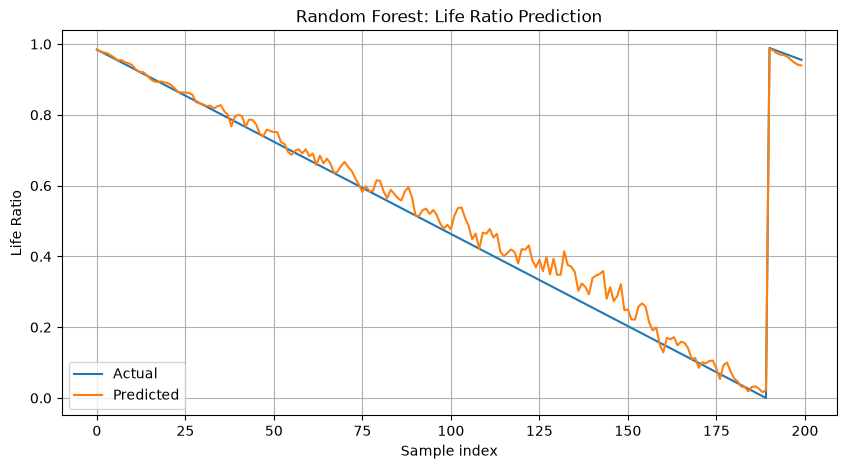

Mean validation residual (Actual - Predicted): -0.004083570237911482


In [25]:
# Plot prediction
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_pred_val[:200], label="Predicted")
plt.title("Random Forest: Life Ratio Prediction")
plt.ylabel("Life Ratio")
plt.xlabel("Sample index")
plt.legend()
plt.grid()
plt.show()

print("Mean validation residual (Actual - Predicted):", (y_val - y_pred_val).mean())

On the validation set, the untuned Random Forest baseline has a mean residual of about -0.004 (Actual - Predicted), i.e. a very slight overprediction of life_ratio on average -- much smaller in relative terms than the ~30-cycle bias seen when RUL was the raw target.

### Hyperparameter tuning with Optuna

In [26]:
import optuna
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np

/home/adamtay/miniforge3/envs/jabil/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [27]:
# Hyperparameter tuning random forest
besr_rf = None
best_rmse = None

def rf_objective(trial):
    global besr_rf, best_rmse

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 5, 100),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        "max_features": trial.suggest_categorical(
            "max_features", ["sqrt", "log2", 0.5, 0.8, None]
        ),
        "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        "random_state": 42,
        "n_jobs": -1
    }

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    if best_rmse is None or rmse < best_rmse:
        best_rmse = rmse
        besr_rf = model

    return rmse


In [28]:
study = optuna.create_study(direction="minimize")
study.optimize(rf_objective, n_trials=100)

[I 2026-07-06 23:29:13,953] A new study created in memory with name: no-name-acdff413-ceba-4009-ab7a-3cd73ff9a611


[I 2026-07-06 23:29:14,272] Trial 0 finished with value: 0.0577722404346548 and parameters: {'n_estimators': 153, 'max_depth': 80, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 0 with value: 0.0577722404346548.


[I 2026-07-06 23:29:15,317] Trial 1 finished with value: 0.05752883226199046 and parameters: {'n_estimators': 564, 'max_depth': 29, 'min_samples_split': 10, 'min_samples_leaf': 1, 'max_features': 0.5, 'bootstrap': True}. Best is trial 1 with value: 0.05752883226199046.


[I 2026-07-06 23:29:15,981] Trial 2 finished with value: 0.057703261283584065 and parameters: {'n_estimators': 278, 'max_depth': 85, 'min_samples_split': 7, 'min_samples_leaf': 10, 'max_features': 0.8, 'bootstrap': True}. Best is trial 1 with value: 0.05752883226199046.


[I 2026-07-06 23:29:16,434] Trial 3 finished with value: 0.05797135724358172 and parameters: {'n_estimators': 320, 'max_depth': 97, 'min_samples_split': 6, 'min_samples_leaf': 10, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 1 with value: 0.05752883226199046.


[I 2026-07-06 23:29:17,735] Trial 4 finished with value: 0.059656516395219544 and parameters: {'n_estimators': 369, 'max_depth': 39, 'min_samples_split': 15, 'min_samples_leaf': 5, 'max_features': 0.8, 'bootstrap': False}. Best is trial 1 with value: 0.05752883226199046.


[I 2026-07-06 23:29:18,470] Trial 5 finished with value: 0.05733176277145292 and parameters: {'n_estimators': 428, 'max_depth': 54, 'min_samples_split': 10, 'min_samples_leaf': 3, 'max_features': 0.5, 'bootstrap': True}. Best is trial 5 with value: 0.05733176277145292.


[I 2026-07-06 23:29:19,268] Trial 6 finished with value: 0.058083293557754066 and parameters: {'n_estimators': 281, 'max_depth': 85, 'min_samples_split': 19, 'min_samples_leaf': 9, 'max_features': None, 'bootstrap': True}. Best is trial 5 with value: 0.05733176277145292.


[I 2026-07-06 23:29:20,391] Trial 7 finished with value: 0.0579499581718746 and parameters: {'n_estimators': 444, 'max_depth': 92, 'min_samples_split': 9, 'min_samples_leaf': 4, 'max_features': 0.8, 'bootstrap': True}. Best is trial 5 with value: 0.05733176277145292.


[I 2026-07-06 23:29:21,477] Trial 8 finished with value: 0.05838440725918205 and parameters: {'n_estimators': 348, 'max_depth': 37, 'min_samples_split': 4, 'min_samples_leaf': 4, 'max_features': None, 'bootstrap': True}. Best is trial 5 with value: 0.05733176277145292.


[I 2026-07-06 23:29:22,456] Trial 9 finished with value: 0.05767228321484568 and parameters: {'n_estimators': 415, 'max_depth': 89, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_features': 0.8, 'bootstrap': True}. Best is trial 5 with value: 0.05733176277145292.


[I 2026-07-06 23:29:23,205] Trial 10 finished with value: 0.06554808443514161 and parameters: {'n_estimators': 578, 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.5, 'bootstrap': False}. Best is trial 5 with value: 0.05733176277145292.


[I 2026-07-06 23:29:24,791] Trial 11 finished with value: 0.05828925066795796 and parameters: {'n_estimators': 579, 'max_depth': 47, 'min_samples_split': 12, 'min_samples_leaf': 1, 'max_features': 0.5, 'bootstrap': False}. Best is trial 5 with value: 0.05733176277145292.


[I 2026-07-06 23:29:25,794] Trial 12 finished with value: 0.057439725169282196 and parameters: {'n_estimators': 501, 'max_depth': 56, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.5, 'bootstrap': True}. Best is trial 5 with value: 0.05733176277145292.


[I 2026-07-06 23:29:26,577] Trial 13 finished with value: 0.0575582423259712 and parameters: {'n_estimators': 484, 'max_depth': 63, 'min_samples_split': 14, 'min_samples_leaf': 3, 'max_features': 'log2', 'bootstrap': True}. Best is trial 5 with value: 0.05733176277145292.


[I 2026-07-06 23:29:27,897] Trial 14 finished with value: 0.058227242005022016 and parameters: {'n_estimators': 497, 'max_depth': 61, 'min_samples_split': 9, 'min_samples_leaf': 2, 'max_features': 0.5, 'bootstrap': False}. Best is trial 5 with value: 0.05733176277145292.


[I 2026-07-06 23:29:28,758] Trial 15 finished with value: 0.05716897407312479 and parameters: {'n_estimators': 507, 'max_depth': 63, 'min_samples_split': 14, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': True}. Best is trial 15 with value: 0.05716897407312479.


[I 2026-07-06 23:29:29,067] Trial 16 finished with value: 0.05761497931095061 and parameters: {'n_estimators': 170, 'max_depth': 70, 'min_samples_split': 16, 'min_samples_leaf': 6, 'max_features': 'log2', 'bootstrap': True}. Best is trial 15 with value: 0.05716897407312479.


[I 2026-07-06 23:29:29,785] Trial 17 finished with value: 0.05718356102937351 and parameters: {'n_estimators': 412, 'max_depth': 19, 'min_samples_split': 13, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 15 with value: 0.05716897407312479.


[I 2026-07-06 23:29:30,332] Trial 18 finished with value: 0.05770493377837559 and parameters: {'n_estimators': 223, 'max_depth': 14, 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': False}. Best is trial 15 with value: 0.05716897407312479.


[I 2026-07-06 23:29:30,608] Trial 19 finished with value: 0.05742647359894807 and parameters: {'n_estimators': 103, 'max_depth': 25, 'min_samples_split': 20, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 15 with value: 0.05716897407312479.


[I 2026-07-06 23:29:31,426] Trial 20 finished with value: 0.05756185247619491 and parameters: {'n_estimators': 527, 'max_depth': 73, 'min_samples_split': 13, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 15 with value: 0.05716897407312479.


[I 2026-07-06 23:29:32,155] Trial 21 finished with value: 0.05735480427561196 and parameters: {'n_estimators': 405, 'max_depth': 49, 'min_samples_split': 12, 'min_samples_leaf': 5, 'max_features': 0.5, 'bootstrap': True}. Best is trial 15 with value: 0.05716897407312479.


[I 2026-07-06 23:29:32,947] Trial 22 finished with value: 0.05716077793936486 and parameters: {'n_estimators': 449, 'max_depth': 19, 'min_samples_split': 14, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 22 with value: 0.05716077793936486.


[I 2026-07-06 23:29:33,727] Trial 23 finished with value: 0.057168466531063326 and parameters: {'n_estimators': 465, 'max_depth': 17, 'min_samples_split': 14, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 22 with value: 0.05716077793936486.


[I 2026-07-06 23:29:34,512] Trial 24 finished with value: 0.06244791399451366 and parameters: {'n_estimators': 460, 'max_depth': 5, 'min_samples_split': 15, 'min_samples_leaf': 8, 'max_features': None, 'bootstrap': True}. Best is trial 22 with value: 0.05716077793936486.


[I 2026-07-06 23:29:35,288] Trial 25 finished with value: 0.05777153552410692 and parameters: {'n_estimators': 517, 'max_depth': 15, 'min_samples_split': 17, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': True}. Best is trial 22 with value: 0.05716077793936486.


[I 2026-07-06 23:29:36,501] Trial 26 finished with value: 0.05757789905742308 and parameters: {'n_estimators': 543, 'max_depth': 37, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': False}. Best is trial 22 with value: 0.05716077793936486.


[I 2026-07-06 23:29:37,290] Trial 27 finished with value: 0.05723105256412711 and parameters: {'n_estimators': 472, 'max_depth': 25, 'min_samples_split': 17, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': True}. Best is trial 22 with value: 0.05716077793936486.


[I 2026-07-06 23:29:37,937] Trial 28 finished with value: 0.05726406356319659 and parameters: {'n_estimators': 368, 'max_depth': 31, 'min_samples_split': 14, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 22 with value: 0.05716077793936486.


[I 2026-07-06 23:29:40,648] Trial 29 finished with value: 0.057612757173761145 and parameters: {'n_estimators': 547, 'max_depth': 17, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 22 with value: 0.05716077793936486.


[I 2026-07-06 23:29:41,451] Trial 30 finished with value: 0.057178946669256006 and parameters: {'n_estimators': 462, 'max_depth': 74, 'min_samples_split': 11, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 22 with value: 0.05716077793936486.


[I 2026-07-06 23:29:42,212] Trial 31 finished with value: 0.05718153215601019 and parameters: {'n_estimators': 456, 'max_depth': 75, 'min_samples_split': 11, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 22 with value: 0.05716077793936486.


[I 2026-07-06 23:29:43,230] Trial 32 finished with value: 0.057124260191407414 and parameters: {'n_estimators': 599, 'max_depth': 78, 'min_samples_split': 14, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:44,199] Trial 33 finished with value: 0.05712932699059728 and parameters: {'n_estimators': 593, 'max_depth': 65, 'min_samples_split': 14, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:45,181] Trial 34 finished with value: 0.0571703555754764 and parameters: {'n_estimators': 599, 'max_depth': 83, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:45,948] Trial 35 finished with value: 0.05855400560193869 and parameters: {'n_estimators': 550, 'max_depth': 10, 'min_samples_split': 13, 'min_samples_leaf': 9, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:46,955] Trial 36 finished with value: 0.05730154654047653 and parameters: {'n_estimators': 600, 'max_depth': 96, 'min_samples_split': 16, 'min_samples_leaf': 5, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:48,539] Trial 37 finished with value: 0.058205893957195776 and parameters: {'n_estimators': 561, 'max_depth': 44, 'min_samples_split': 7, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:49,491] Trial 38 finished with value: 0.05927612139973413 and parameters: {'n_estimators': 279, 'max_depth': 79, 'min_samples_split': 14, 'min_samples_leaf': 10, 'max_features': 0.8, 'bootstrap': False}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:50,007] Trial 39 finished with value: 0.05786108563283063 and parameters: {'n_estimators': 331, 'max_depth': 31, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 'log2', 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:50,678] Trial 40 finished with value: 0.05718432520791681 and parameters: {'n_estimators': 395, 'max_depth': 22, 'min_samples_split': 19, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:51,569] Trial 41 finished with value: 0.0571503136604883 and parameters: {'n_estimators': 521, 'max_depth': 66, 'min_samples_split': 14, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:52,465] Trial 42 finished with value: 0.057205432362867674 and parameters: {'n_estimators': 529, 'max_depth': 68, 'min_samples_split': 13, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:53,400] Trial 43 finished with value: 0.05713006715264774 and parameters: {'n_estimators': 576, 'max_depth': 100, 'min_samples_split': 11, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:54,750] Trial 44 finished with value: 0.05785496098137398 and parameters: {'n_estimators': 578, 'max_depth': 100, 'min_samples_split': 11, 'min_samples_leaf': 7, 'max_features': 0.8, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:55,710] Trial 45 finished with value: 0.05723215951490743 and parameters: {'n_estimators': 564, 'max_depth': 91, 'min_samples_split': 9, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:57,370] Trial 46 finished with value: 0.058202325078826375 and parameters: {'n_estimators': 585, 'max_depth': 54, 'min_samples_split': 7, 'min_samples_leaf': 7, 'max_features': None, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:58,409] Trial 47 finished with value: 0.05795793965143425 and parameters: {'n_estimators': 433, 'max_depth': 81, 'min_samples_split': 10, 'min_samples_leaf': 5, 'max_features': 0.5, 'bootstrap': False}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:59,217] Trial 48 finished with value: 0.05715118959356233 and parameters: {'n_estimators': 490, 'max_depth': 59, 'min_samples_split': 12, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:29:59,981] Trial 49 finished with value: 0.05752794513420297 and parameters: {'n_estimators': 488, 'max_depth': 60, 'min_samples_split': 12, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:00,882] Trial 50 finished with value: 0.05722777746939959 and parameters: {'n_estimators': 531, 'max_depth': 66, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:01,770] Trial 51 finished with value: 0.0571449362983636 and parameters: {'n_estimators': 511, 'max_depth': 78, 'min_samples_split': 11, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:02,747] Trial 52 finished with value: 0.05713884187495508 and parameters: {'n_estimators': 565, 'max_depth': 57, 'min_samples_split': 11, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:03,693] Trial 53 finished with value: 0.05713027474125671 and parameters: {'n_estimators': 570, 'max_depth': 86, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:04,700] Trial 54 finished with value: 0.057236301116572665 and parameters: {'n_estimators': 567, 'max_depth': 88, 'min_samples_split': 5, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:06,185] Trial 55 finished with value: 0.057937880489677594 and parameters: {'n_estimators': 600, 'max_depth': 95, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_features': 0.8, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:07,480] Trial 56 finished with value: 0.05767251700349104 and parameters: {'n_estimators': 549, 'max_depth': 78, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': False}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:08,564] Trial 57 finished with value: 0.05713006715264774 and parameters: {'n_estimators': 576, 'max_depth': 86, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:09,499] Trial 58 finished with value: 0.05760835244384767 and parameters: {'n_estimators': 575, 'max_depth': 87, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:12,493] Trial 59 finished with value: 0.05723535575402482 and parameters: {'n_estimators': 584, 'max_depth': 93, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:13,568] Trial 60 finished with value: 0.05713547496850188 and parameters: {'n_estimators': 559, 'max_depth': 72, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:14,650] Trial 61 finished with value: 0.05713427572423768 and parameters: {'n_estimators': 555, 'max_depth': 71, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:15,650] Trial 62 finished with value: 0.057204094843165985 and parameters: {'n_estimators': 542, 'max_depth': 84, 'min_samples_split': 5, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:16,774] Trial 63 finished with value: 0.05723367668621259 and parameters: {'n_estimators': 589, 'max_depth': 71, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:17,798] Trial 64 finished with value: 0.057134174798070106 and parameters: {'n_estimators': 556, 'max_depth': 100, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:19,486] Trial 65 finished with value: 0.058144970379992916 and parameters: {'n_estimators': 534, 'max_depth': 98, 'min_samples_split': 4, 'min_samples_leaf': 8, 'max_features': None, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:20,445] Trial 66 finished with value: 0.0571449362983636 and parameters: {'n_estimators': 511, 'max_depth': 89, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:21,931] Trial 67 finished with value: 0.05773082625988443 and parameters: {'n_estimators': 583, 'max_depth': 93, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': False}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:22,925] Trial 68 finished with value: 0.05713678239613385 and parameters: {'n_estimators': 553, 'max_depth': 100, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:23,852] Trial 69 finished with value: 0.057612708114251454 and parameters: {'n_estimators': 573, 'max_depth': 86, 'min_samples_split': 7, 'min_samples_leaf': 8, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 32 with value: 0.057124260191407414.


[I 2026-07-06 23:30:24,888] Trial 70 finished with value: 0.05712281558593137 and parameters: {'n_estimators': 600, 'max_depth': 76, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:25,953] Trial 71 finished with value: 0.05712489257291473 and parameters: {'n_estimators': 598, 'max_depth': 76, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:27,006] Trial 72 finished with value: 0.05712281558593137 and parameters: {'n_estimators': 600, 'max_depth': 76, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:28,081] Trial 73 finished with value: 0.05719398937332244 and parameters: {'n_estimators': 600, 'max_depth': 76, 'min_samples_split': 2, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:29,121] Trial 74 finished with value: 0.05723367668621259 and parameters: {'n_estimators': 589, 'max_depth': 81, 'min_samples_split': 3, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:30,061] Trial 75 finished with value: 0.057606376042372745 and parameters: {'n_estimators': 574, 'max_depth': 82, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 'log2', 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:31,170] Trial 76 finished with value: 0.05723367668621259 and parameters: {'n_estimators': 589, 'max_depth': 77, 'min_samples_split': 2, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:32,575] Trial 77 finished with value: 0.0578538234136102 and parameters: {'n_estimators': 539, 'max_depth': 68, 'min_samples_split': 4, 'min_samples_leaf': 7, 'max_features': 0.8, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:33,679] Trial 78 finished with value: 0.05716163954788293 and parameters: {'n_estimators': 599, 'max_depth': 63, 'min_samples_split': 3, 'min_samples_leaf': 9, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:35,112] Trial 79 finished with value: 0.05766178755483822 and parameters: {'n_estimators': 570, 'max_depth': 86, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': False}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:36,785] Trial 80 finished with value: 0.05828393535829363 and parameters: {'n_estimators': 522, 'max_depth': 74, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': None, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:37,850] Trial 81 finished with value: 0.057131139188278085 and parameters: {'n_estimators': 584, 'max_depth': 91, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:38,905] Trial 82 finished with value: 0.057127849271321196 and parameters: {'n_estimators': 581, 'max_depth': 91, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:39,929] Trial 83 finished with value: 0.057138614685424534 and parameters: {'n_estimators': 566, 'max_depth': 83, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:41,026] Trial 84 finished with value: 0.05719096957683793 and parameters: {'n_estimators': 591, 'max_depth': 94, 'min_samples_split': 3, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:43,885] Trial 85 finished with value: 0.05714251631602135 and parameters: {'n_estimators': 545, 'max_depth': 79, 'min_samples_split': 8, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:44,330] Trial 86 finished with value: 0.05724839985747468 and parameters: {'n_estimators': 220, 'max_depth': 97, 'min_samples_split': 4, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:45,380] Trial 87 finished with value: 0.05716861833123014 and parameters: {'n_estimators': 576, 'max_depth': 90, 'min_samples_split': 15, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:46,347] Trial 88 finished with value: 0.057583187948979105 and parameters: {'n_estimators': 600, 'max_depth': 84, 'min_samples_split': 18, 'min_samples_leaf': 6, 'max_features': 'sqrt', 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:47,271] Trial 89 finished with value: 0.057150473566574475 and parameters: {'n_estimators': 501, 'max_depth': 80, 'min_samples_split': 2, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:48,269] Trial 90 finished with value: 0.05720450120432902 and parameters: {'n_estimators': 560, 'max_depth': 76, 'min_samples_split': 13, 'min_samples_leaf': 8, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:49,350] Trial 91 finished with value: 0.057130541271438386 and parameters: {'n_estimators': 583, 'max_depth': 88, 'min_samples_split': 6, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:50,395] Trial 92 finished with value: 0.05712915820806573 and parameters: {'n_estimators': 577, 'max_depth': 87, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:51,452] Trial 93 finished with value: 0.0571309792299915 and parameters: {'n_estimators': 575, 'max_depth': 69, 'min_samples_split': 5, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:52,466] Trial 94 finished with value: 0.05722998359220994 and parameters: {'n_estimators': 544, 'max_depth': 85, 'min_samples_split': 4, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:53,378] Trial 95 finished with value: 0.057617480459240845 and parameters: {'n_estimators': 562, 'max_depth': 73, 'min_samples_split': 16, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:54,496] Trial 96 finished with value: 0.05723367668621259 and parameters: {'n_estimators': 589, 'max_depth': 64, 'min_samples_split': 7, 'min_samples_leaf': 6, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:55,864] Trial 97 finished with value: 0.057860956989564026 and parameters: {'n_estimators': 535, 'max_depth': 92, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 0.8, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:57,510] Trial 98 finished with value: 0.05848101962114245 and parameters: {'n_estimators': 553, 'max_depth': 81, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'bootstrap': False}. Best is trial 70 with value: 0.05712281558593137.


[I 2026-07-06 23:30:58,522] Trial 99 finished with value: 0.057130274741256704 and parameters: {'n_estimators': 570, 'max_depth': 96, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}. Best is trial 70 with value: 0.05712281558593137.


In [29]:
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

Best RMSE: 0.05712281558593137
Best params: {'n_estimators': 600, 'max_depth': 76, 'min_samples_split': 3, 'min_samples_leaf': 7, 'max_features': 0.5, 'bootstrap': True}


In [30]:
y_pred_train = besr_rf.predict(X_train)
y_pred_val = besr_rf.predict(X_val)
evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 0.0515
MAE : 0.0375
R2  : 0.9676

Validation Performance:
RMSE: 0.0571
MAE : 0.0430
R2  : 0.9601


In [31]:
import xgboost as xgb

best_xg = None
xgb_best_rmse = None


def xgb_objective(trial):
    global best_xg, xgb_best_rmse

    params = {
        "n_estimators": trial.suggest_int("n_estimators", 100, 500),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 5.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 5.0),
        "random_state": 42,
        "n_jobs": -1,
        "objective": "reg:squarederror",
    }

    model = xgb.XGBRegressor(**params)
    model.fit(X_train, y_train)

    preds = model.predict(X_val)
    rmse = np.sqrt(mean_squared_error(y_val, preds))

    if xgb_best_rmse is None or rmse < xgb_best_rmse:
        xgb_best_rmse = rmse
        best_xg = model

    return rmse


In [32]:
study = optuna.create_study(direction="minimize")
study.optimize(xgb_objective, n_trials=100)

[I 2026-07-06 23:30:58,844] A new study created in memory with name: no-name-24dd8a59-2625-4e00-bab1-85133796edc3


[I 2026-07-06 23:30:59,176] Trial 0 finished with value: 0.06729586929854199 and parameters: {'n_estimators': 131, 'max_depth': 7, 'learning_rate': 0.04180877375697041, 'subsample': 0.6508310406454181, 'colsample_bytree': 0.9910043233214736, 'min_child_weight': 4, 'gamma': 3.5063221604248356, 'reg_alpha': 2.9648384450428997, 'reg_lambda': 2.077065576502481}. Best is trial 0 with value: 0.06729586929854199.


[I 2026-07-06 23:30:59,309] Trial 1 finished with value: 0.06154798297639295 and parameters: {'n_estimators': 299, 'max_depth': 9, 'learning_rate': 0.280780667934345, 'subsample': 0.7071720857591486, 'colsample_bytree': 0.8379841416036562, 'min_child_weight': 6, 'gamma': 1.1401558154445368, 'reg_alpha': 0.3199355779436591, 'reg_lambda': 2.428120449233575}. Best is trial 1 with value: 0.06154798297639295.


[I 2026-07-06 23:30:59,570] Trial 2 finished with value: 0.058186318664950484 and parameters: {'n_estimators': 328, 'max_depth': 5, 'learning_rate': 0.027359486194195586, 'subsample': 0.6094145123556036, 'colsample_bytree': 0.8465776330147518, 'min_child_weight': 7, 'gamma': 0.3772106422624738, 'reg_alpha': 0.7773903718063802, 'reg_lambda': 0.09412745376610021}. Best is trial 2 with value: 0.058186318664950484.


[I 2026-07-06 23:30:59,728] Trial 3 finished with value: 0.05921087611514513 and parameters: {'n_estimators': 423, 'max_depth': 3, 'learning_rate': 0.0655614138441284, 'subsample': 0.914632243364148, 'colsample_bytree': 0.9620029060558116, 'min_child_weight': 6, 'gamma': 0.4203642726420487, 'reg_alpha': 1.921423092034737, 'reg_lambda': 1.9914619914808873}. Best is trial 2 with value: 0.058186318664950484.


[I 2026-07-06 23:30:59,914] Trial 4 finished with value: 0.07310640085640005 and parameters: {'n_estimators': 271, 'max_depth': 10, 'learning_rate': 0.22894874494614212, 'subsample': 0.6424776595363255, 'colsample_bytree': 0.5344554570214503, 'min_child_weight': 4, 'gamma': 2.1781025883470106, 'reg_alpha': 0.5472125255667942, 'reg_lambda': 2.6617980742066387}. Best is trial 2 with value: 0.058186318664950484.


[I 2026-07-06 23:31:00,224] Trial 5 finished with value: 0.06176632232975938 and parameters: {'n_estimators': 396, 'max_depth': 3, 'learning_rate': 0.01054627574564486, 'subsample': 0.8060216236380568, 'colsample_bytree': 0.793137206806366, 'min_child_weight': 7, 'gamma': 1.726850337579346, 'reg_alpha': 0.016870460241318885, 'reg_lambda': 0.08772215939979178}. Best is trial 2 with value: 0.058186318664950484.


[I 2026-07-06 23:31:00,353] Trial 6 finished with value: 0.06518696320068837 and parameters: {'n_estimators': 301, 'max_depth': 9, 'learning_rate': 0.05480725506414642, 'subsample': 0.8322323096271157, 'colsample_bytree': 0.7070388134072405, 'min_child_weight': 3, 'gamma': 3.37069038836018, 'reg_alpha': 1.8614170268815151, 'reg_lambda': 3.98382784474345}. Best is trial 2 with value: 0.058186318664950484.


[I 2026-07-06 23:31:00,541] Trial 7 finished with value: 0.0657574277710113 and parameters: {'n_estimators': 275, 'max_depth': 10, 'learning_rate': 0.013084104741686782, 'subsample': 0.8577360489935524, 'colsample_bytree': 0.9444609491074254, 'min_child_weight': 9, 'gamma': 3.507938274059616, 'reg_alpha': 4.026089204208593, 'reg_lambda': 4.197353104909837}. Best is trial 2 with value: 0.058186318664950484.


[I 2026-07-06 23:31:00,685] Trial 8 finished with value: 0.06571421083665624 and parameters: {'n_estimators': 265, 'max_depth': 9, 'learning_rate': 0.024005555458461177, 'subsample': 0.9139223633650548, 'colsample_bytree': 0.8125183689210937, 'min_child_weight': 8, 'gamma': 4.0621923213456865, 'reg_alpha': 1.9297310952112472, 'reg_lambda': 1.6710968206734726}. Best is trial 2 with value: 0.058186318664950484.


[I 2026-07-06 23:31:00,856] Trial 9 finished with value: 0.0691588978923051 and parameters: {'n_estimators': 355, 'max_depth': 3, 'learning_rate': 0.034582974074541424, 'subsample': 0.9346649026723246, 'colsample_bytree': 0.5238521716364495, 'min_child_weight': 6, 'gamma': 3.807239929086993, 'reg_alpha': 1.0626001533050522, 'reg_lambda': 4.719044296860735}. Best is trial 2 with value: 0.058186318664950484.


[I 2026-07-06 23:31:01,154] Trial 10 finished with value: 0.07333479240489382 and parameters: {'n_estimators': 500, 'max_depth': 6, 'learning_rate': 0.11383078833296209, 'subsample': 0.5007027339741382, 'colsample_bytree': 0.6525695784422509, 'min_child_weight': 1, 'gamma': 4.766908862744824, 'reg_alpha': 4.812025428280499, 'reg_lambda': 0.12227588302014958}. Best is trial 2 with value: 0.058186318664950484.


[I 2026-07-06 23:31:01,404] Trial 11 finished with value: 0.05759059289249452 and parameters: {'n_estimators': 444, 'max_depth': 5, 'learning_rate': 0.08425013643302863, 'subsample': 0.5111059262763427, 'colsample_bytree': 0.9112054929540669, 'min_child_weight': 10, 'gamma': 0.07452479335004325, 'reg_alpha': 1.722239188317469, 'reg_lambda': 1.1721084728112592}. Best is trial 11 with value: 0.05759059289249452.


[I 2026-07-06 23:31:03,204] Trial 12 finished with value: 0.05772197872922156 and parameters: {'n_estimators': 495, 'max_depth': 5, 'learning_rate': 0.10841969843806179, 'subsample': 0.5001603650475344, 'colsample_bytree': 0.8731839942101804, 'min_child_weight': 10, 'gamma': 0.10278590023519801, 'reg_alpha': 1.2189441714795972, 'reg_lambda': 0.9872237429528675}. Best is trial 11 with value: 0.05759059289249452.


[I 2026-07-06 23:31:09,568] Trial 13 finished with value: 0.0577709709422986 and parameters: {'n_estimators': 485, 'max_depth': 5, 'learning_rate': 0.13733772848050124, 'subsample': 0.5027712938720337, 'colsample_bytree': 0.9053088835808298, 'min_child_weight': 10, 'gamma': 0.03852400746213387, 'reg_alpha': 2.422299313094922, 'reg_lambda': 1.0152849162168165}. Best is trial 11 with value: 0.05759059289249452.


[I 2026-07-06 23:31:09,765] Trial 14 finished with value: 0.06383465196255003 and parameters: {'n_estimators': 434, 'max_depth': 5, 'learning_rate': 0.09435038780480066, 'subsample': 0.5450233286419138, 'colsample_bytree': 0.7239186993920665, 'min_child_weight': 10, 'gamma': 1.3434816080151695, 'reg_alpha': 1.3002744048186419, 'reg_lambda': 1.2986637646822494}. Best is trial 11 with value: 0.05759059289249452.


[I 2026-07-06 23:31:10,044] Trial 15 finished with value: 0.0611657585953078 and parameters: {'n_estimators': 447, 'max_depth': 7, 'learning_rate': 0.1739761925969489, 'subsample': 0.5708153523846266, 'colsample_bytree': 0.896892106668066, 'min_child_weight': 9, 'gamma': 0.7189462022285888, 'reg_alpha': 3.0495861825386985, 'reg_lambda': 0.8428598754130097}. Best is trial 11 with value: 0.05759059289249452.


[I 2026-07-06 23:31:10,230] Trial 16 finished with value: 0.0573641426771108 and parameters: {'n_estimators': 393, 'max_depth': 4, 'learning_rate': 0.08695494374946802, 'subsample': 0.7139949219769687, 'colsample_bytree': 0.8890586703417287, 'min_child_weight': 10, 'gamma': 0.035635047520338047, 'reg_alpha': 1.374607678618737, 'reg_lambda': 2.9763846684223667}. Best is trial 16 with value: 0.0573641426771108.


[I 2026-07-06 23:31:10,385] Trial 17 finished with value: 0.06477804125160667 and parameters: {'n_estimators': 373, 'max_depth': 4, 'learning_rate': 0.07227968828827386, 'subsample': 0.7361784420680594, 'colsample_bytree': 0.7641796922224344, 'min_child_weight': 8, 'gamma': 2.349240343506585, 'reg_alpha': 2.9252898249379706, 'reg_lambda': 3.1672343885369902}. Best is trial 16 with value: 0.0573641426771108.


[I 2026-07-06 23:31:10,513] Trial 18 finished with value: 0.0605784036864994 and parameters: {'n_estimators': 204, 'max_depth': 4, 'learning_rate': 0.18263342726786133, 'subsample': 0.9963043224515118, 'colsample_bytree': 0.9409165762122987, 'min_child_weight': 9, 'gamma': 1.0167370171004257, 'reg_alpha': 1.6169226286725047, 'reg_lambda': 3.359354153751595}. Best is trial 16 with value: 0.0573641426771108.


[I 2026-07-06 23:31:10,794] Trial 19 finished with value: 0.060565052314570156 and parameters: {'n_estimators': 385, 'max_depth': 7, 'learning_rate': 0.07651423705425174, 'subsample': 0.7404692548747849, 'colsample_bytree': 0.9939765936134131, 'min_child_weight': 8, 'gamma': 0.7674924103593134, 'reg_alpha': 2.3402556050702152, 'reg_lambda': 3.264061593859257}. Best is trial 16 with value: 0.0573641426771108.


[I 2026-07-06 23:31:11,018] Trial 20 finished with value: 0.06301798079348324 and parameters: {'n_estimators': 452, 'max_depth': 6, 'learning_rate': 0.042251021315943736, 'subsample': 0.6707026028517121, 'colsample_bytree': 0.9106968123159265, 'min_child_weight': 10, 'gamma': 1.6825725568413572, 'reg_alpha': 3.586044928997512, 'reg_lambda': 2.7363766586289993}. Best is trial 16 with value: 0.0573641426771108.


[I 2026-07-06 23:31:11,249] Trial 21 finished with value: 0.05740981027864109 and parameters: {'n_estimators': 472, 'max_depth': 4, 'learning_rate': 0.10660545727663143, 'subsample': 0.5641745898532979, 'colsample_bytree': 0.8684924821276377, 'min_child_weight': 10, 'gamma': 0.06966633418906577, 'reg_alpha': 1.1489844390595945, 'reg_lambda': 0.6672573607545352}. Best is trial 16 with value: 0.0573641426771108.


[I 2026-07-06 23:31:11,451] Trial 22 finished with value: 0.05950456769402216 and parameters: {'n_estimators': 409, 'max_depth': 4, 'learning_rate': 0.13079840972006365, 'subsample': 0.5741138908778944, 'colsample_bytree': 0.8659787532904912, 'min_child_weight': 9, 'gamma': 0.5007200224771289, 'reg_alpha': 0.9102147674199954, 'reg_lambda': 0.5549323422519764}. Best is trial 16 with value: 0.0573641426771108.


[I 2026-07-06 23:31:12,080] Trial 23 finished with value: 0.05653286637769282 and parameters: {'n_estimators': 454, 'max_depth': 4, 'learning_rate': 0.08837648283803129, 'subsample': 0.5940965357528702, 'colsample_bytree': 0.7748979505467251, 'min_child_weight': 10, 'gamma': 0.009181715891011813, 'reg_alpha': 1.5104589710662502, 'reg_lambda': 1.4122107173450453}. Best is trial 23 with value: 0.05653286637769282.


[I 2026-07-06 23:31:12,378] Trial 24 finished with value: 0.055942320611351015 and parameters: {'n_estimators': 468, 'max_depth': 4, 'learning_rate': 0.05599182358466511, 'subsample': 0.6100670107412818, 'colsample_bytree': 0.6464364814534226, 'min_child_weight': 9, 'gamma': 0.010499646601437984, 'reg_alpha': 1.3441045701832137, 'reg_lambda': 1.610024522671701}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:12,567] Trial 25 finished with value: 0.061578428372197104 and parameters: {'n_estimators': 345, 'max_depth': 3, 'learning_rate': 0.059172367623220534, 'subsample': 0.7081149400511006, 'colsample_bytree': 0.605398473407501, 'min_child_weight': 8, 'gamma': 0.7708814143885448, 'reg_alpha': 2.353943055435926, 'reg_lambda': 1.7440513416906203}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:12,883] Trial 26 finished with value: 0.06201325274871969 and parameters: {'n_estimators': 411, 'max_depth': 4, 'learning_rate': 0.01788063365758198, 'subsample': 0.6191207757828534, 'colsample_bytree': 0.6226633289284205, 'min_child_weight': 9, 'gamma': 1.3909339212273013, 'reg_alpha': 0.5205838576556859, 'reg_lambda': 1.4895237754944253}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:16,929] Trial 27 finished with value: 0.0592636418568092 and parameters: {'n_estimators': 459, 'max_depth': 6, 'learning_rate': 0.051163472524505926, 'subsample': 0.7760091546283284, 'colsample_bytree': 0.7157115894471888, 'min_child_weight': 7, 'gamma': 0.48061843061562687, 'reg_alpha': 1.5857733077961138, 'reg_lambda': 2.2707220059858155}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:18,816] Trial 28 finished with value: 0.06193962729814507 and parameters: {'n_estimators': 382, 'max_depth': 4, 'learning_rate': 0.04359763385798746, 'subsample': 0.6105659431270809, 'colsample_bytree': 0.5747247436758204, 'min_child_weight': 9, 'gamma': 0.9367788893790546, 'reg_alpha': 1.4490506877370022, 'reg_lambda': 3.9154340169169406}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:18,906] Trial 29 finished with value: 0.061936526320723044 and parameters: {'n_estimators': 109, 'max_depth': 3, 'learning_rate': 0.034229058907925776, 'subsample': 0.6759874591547387, 'colsample_bytree': 0.6739753779046437, 'min_child_weight': 8, 'gamma': 0.4348848971173489, 'reg_alpha': 2.2139428036752276, 'reg_lambda': 1.9741722807749187}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:19,185] Trial 30 finished with value: 0.057883084635209324 and parameters: {'n_estimators': 198, 'max_depth': 7, 'learning_rate': 0.1691607144933676, 'subsample': 0.6415659814915865, 'colsample_bytree': 0.7444851455503215, 'min_child_weight': 1, 'gamma': 9.471080465756933e-05, 'reg_alpha': 2.8865758507147357, 'reg_lambda': 2.8599001338012213}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:19,426] Trial 31 finished with value: 0.05867674284232587 and parameters: {'n_estimators': 470, 'max_depth': 4, 'learning_rate': 0.09554735994567673, 'subsample': 0.5845889624081086, 'colsample_bytree': 0.7900567736253831, 'min_child_weight': 10, 'gamma': 0.3424133996054337, 'reg_alpha': 1.035324239013391, 'reg_lambda': 0.5654085774754705}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:19,648] Trial 32 finished with value: 0.058193610114886184 and parameters: {'n_estimators': 474, 'max_depth': 4, 'learning_rate': 0.14232098561029058, 'subsample': 0.5503037827778953, 'colsample_bytree': 0.823056344006924, 'min_child_weight': 10, 'gamma': 0.23888373468633112, 'reg_alpha': 0.754970218596012, 'reg_lambda': 0.5729063281851884}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:19,839] Trial 33 finished with value: 0.05922204749152104 and parameters: {'n_estimators': 423, 'max_depth': 5, 'learning_rate': 0.08471392663009214, 'subsample': 0.69813621988545, 'colsample_bytree': 0.8519891477321475, 'min_child_weight': 9, 'gamma': 0.6908005353238682, 'reg_alpha': 0.14709063209846263, 'reg_lambda': 1.4320428390167652}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:20,073] Trial 34 finished with value: 0.06411509004877793 and parameters: {'n_estimators': 459, 'max_depth': 3, 'learning_rate': 0.06686767118455322, 'subsample': 0.5417171556464122, 'colsample_bytree': 0.6622440373350761, 'min_child_weight': 10, 'gamma': 1.2318087510788327, 'reg_alpha': 1.2970256464047834, 'reg_lambda': 2.3275816396718594}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:20,272] Trial 35 finished with value: 0.060225660228266094 and parameters: {'n_estimators': 427, 'max_depth': 4, 'learning_rate': 0.2527382520740127, 'subsample': 0.5997605913486994, 'colsample_bytree': 0.7716267620713979, 'min_child_weight': 7, 'gamma': 0.3242294649149687, 'reg_alpha': 0.47152243594429355, 'reg_lambda': 1.9620108941836958}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:20,515] Trial 36 finished with value: 0.06012434233339988 and parameters: {'n_estimators': 357, 'max_depth': 6, 'learning_rate': 0.10949158783080175, 'subsample': 0.6464147307462081, 'colsample_bytree': 0.9607980326172297, 'min_child_weight': 9, 'gamma': 0.6618098929573482, 'reg_alpha': 2.105340936046843, 'reg_lambda': 0.7233791333639747}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:20,908] Trial 37 finished with value: 0.05647892646906137 and parameters: {'n_estimators': 402, 'max_depth': 5, 'learning_rate': 0.05358296070142462, 'subsample': 0.6256904073950987, 'colsample_bytree': 0.8262332704261267, 'min_child_weight': 8, 'gamma': 0.009075841393856114, 'reg_alpha': 0.753683255073728, 'reg_lambda': 4.876068106137526}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:21,119] Trial 38 finished with value: 0.0606449952861972 and parameters: {'n_estimators': 324, 'max_depth': 5, 'learning_rate': 0.03146270219001942, 'subsample': 0.6294806607890522, 'colsample_bytree': 0.8315794008399795, 'min_child_weight': 7, 'gamma': 1.087191122751394, 'reg_alpha': 0.6549739163757913, 'reg_lambda': 4.3722003770015}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:21,283] Trial 39 finished with value: 0.0590755282163787 and parameters: {'n_estimators': 328, 'max_depth': 3, 'learning_rate': 0.050219402633395, 'subsample': 0.6824506874105852, 'colsample_bytree': 0.5601637897271529, 'min_child_weight': 4, 'gamma': 0.3123439405636796, 'reg_alpha': 0.2666974516335543, 'reg_lambda': 3.605220791419357}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:21,467] Trial 40 finished with value: 0.0588878416313724 and parameters: {'n_estimators': 396, 'max_depth': 8, 'learning_rate': 0.06098665999432465, 'subsample': 0.7544533471306265, 'colsample_bytree': 0.8065604748612997, 'min_child_weight': 6, 'gamma': 0.5341415166099011, 'reg_alpha': 1.9959599891502422, 'reg_lambda': 4.8028484295263905}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:21,667] Trial 41 finished with value: 0.057303491426879204 and parameters: {'n_estimators': 410, 'max_depth': 4, 'learning_rate': 0.0759353921384524, 'subsample': 0.5929162286013273, 'colsample_bytree': 0.8656242207790728, 'min_child_weight': 8, 'gamma': 0.06535433802460174, 'reg_alpha': 0.9295197272129954, 'reg_lambda': 0.37819262169663714}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:21,884] Trial 42 finished with value: 0.057821977652243436 and parameters: {'n_estimators': 405, 'max_depth': 5, 'learning_rate': 0.04791169758212153, 'subsample': 0.5918097295946496, 'colsample_bytree': 0.8428813736259569, 'min_child_weight': 8, 'gamma': 0.2436095995115387, 'reg_alpha': 0.8414915708241766, 'reg_lambda': 0.2583398776061765}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:22,062] Trial 43 finished with value: 0.05869358335290666 and parameters: {'n_estimators': 373, 'max_depth': 3, 'learning_rate': 0.07209161159660261, 'subsample': 0.6576186338106399, 'colsample_bytree': 0.8854642040085525, 'min_child_weight': 8, 'gamma': 0.23473369009017003, 'reg_alpha': 1.444316325873668, 'reg_lambda': 4.497682575811745}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:22,282] Trial 44 finished with value: 0.060729153118458334 and parameters: {'n_estimators': 435, 'max_depth': 5, 'learning_rate': 0.03812396858114598, 'subsample': 0.5303880722890787, 'colsample_bytree': 0.9272087231249043, 'min_child_weight': 5, 'gamma': 0.9249212444040507, 'reg_alpha': 0.9668868801447696, 'reg_lambda': 2.592796525173809}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:22,531] Trial 45 finished with value: 0.059520442268114565 and parameters: {'n_estimators': 394, 'max_depth': 4, 'learning_rate': 0.05679129294846834, 'subsample': 0.6193088754497174, 'colsample_bytree': 0.7816049946900179, 'min_child_weight': 7, 'gamma': 0.6051241967503469, 'reg_alpha': 1.8042380353500902, 'reg_lambda': 4.9414655626717305}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:22,929] Trial 46 finished with value: 0.05617061201218068 and parameters: {'n_estimators': 423, 'max_depth': 5, 'learning_rate': 0.024208218373421277, 'subsample': 0.7153968788678826, 'colsample_bytree': 0.8111255906331178, 'min_child_weight': 9, 'gamma': 0.016135827371982596, 'reg_alpha': 0.48064728241252, 'reg_lambda': 3.7744232567534803}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:23,196] Trial 47 finished with value: 0.05799832635900769 and parameters: {'n_estimators': 422, 'max_depth': 6, 'learning_rate': 0.02481380267858097, 'subsample': 0.8193892585496569, 'colsample_bytree': 0.5020333706116032, 'min_child_weight': 8, 'gamma': 0.24551977563302202, 'reg_alpha': 0.38850643687340813, 'reg_lambda': 3.879870368063336}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:23,460] Trial 48 finished with value: 0.06155638803366722 and parameters: {'n_estimators': 488, 'max_depth': 5, 'learning_rate': 0.018254427415653425, 'subsample': 0.7909830958424772, 'colsample_bytree': 0.6928127567870666, 'min_child_weight': 9, 'gamma': 1.5698363761599698, 'reg_alpha': 0.10415990089434174, 'reg_lambda': 3.554675938808993}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:23,745] Trial 49 finished with value: 0.06916620864570883 and parameters: {'n_estimators': 444, 'max_depth': 5, 'learning_rate': 0.010062889896980884, 'subsample': 0.593709938462079, 'colsample_bytree': 0.754896678209732, 'min_child_weight': 7, 'gamma': 4.894339773462505, 'reg_alpha': 0.6269670292636766, 'reg_lambda': 0.28004789888412995}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:23,992] Trial 50 finished with value: 0.06460773169018162 and parameters: {'n_estimators': 350, 'max_depth': 6, 'learning_rate': 0.018169567773106576, 'subsample': 0.6307816627422629, 'colsample_bytree': 0.8044146056313044, 'min_child_weight': 9, 'gamma': 2.201093585114508, 'reg_alpha': 4.733063229870503, 'reg_lambda': 0.013557826471144785}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:24,324] Trial 51 finished with value: 0.05692968784063218 and parameters: {'n_estimators': 415, 'max_depth': 4, 'learning_rate': 0.08587049938006643, 'subsample': 0.6983000390440874, 'colsample_bytree': 0.8542790390631905, 'min_child_weight': 9, 'gamma': 0.004573056213241137, 'reg_alpha': 1.4112169012188684, 'reg_lambda': 3.0966271523023696}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:24,634] Trial 52 finished with value: 0.05672085220952052 and parameters: {'n_estimators': 420, 'max_depth': 4, 'learning_rate': 0.013585442032298119, 'subsample': 0.7263837070437398, 'colsample_bytree': 0.7426332738394251, 'min_child_weight': 8, 'gamma': 0.014618421315056418, 'reg_alpha': 1.158681318492271, 'reg_lambda': 4.138510101251497}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:24,968] Trial 53 finished with value: 0.05674275287649997 and parameters: {'n_estimators': 438, 'max_depth': 3, 'learning_rate': 0.02064698604930158, 'subsample': 0.7253296393885132, 'colsample_bytree': 0.7360942286098412, 'min_child_weight': 9, 'gamma': 0.018848099471265038, 'reg_alpha': 1.6296994736887898, 'reg_lambda': 4.191530783969891}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:25,224] Trial 54 finished with value: 0.059430005627198426 and parameters: {'n_estimators': 439, 'max_depth': 3, 'learning_rate': 0.012268721012303242, 'subsample': 0.8457027024335921, 'colsample_bytree': 0.7342531938271089, 'min_child_weight': 8, 'gamma': 0.44640848132879446, 'reg_alpha': 1.670411388791519, 'reg_lambda': 4.533140513943113}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:25,473] Trial 55 finished with value: 0.0605196515028659 and parameters: {'n_estimators': 482, 'max_depth': 3, 'learning_rate': 0.015603334564511616, 'subsample': 0.7620976182826716, 'colsample_bytree': 0.6949138769292899, 'min_child_weight': 9, 'gamma': 0.827758385135019, 'reg_alpha': 1.1507885238562632, 'reg_lambda': 4.172207334549706}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:25,688] Trial 56 finished with value: 0.06567441707666594 and parameters: {'n_estimators': 461, 'max_depth': 5, 'learning_rate': 0.028189842093747138, 'subsample': 0.6620823467963826, 'colsample_bytree': 0.6319218540412401, 'min_child_weight': 8, 'gamma': 2.977722053646259, 'reg_alpha': 2.6110282645111944, 'reg_lambda': 4.19225810278188}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:25,905] Trial 57 finished with value: 0.058409719131363926 and parameters: {'n_estimators': 365, 'max_depth': 3, 'learning_rate': 0.021402234472130837, 'subsample': 0.7273214378062451, 'colsample_bytree': 0.7483757227499425, 'min_child_weight': 10, 'gamma': 0.1947894206679891, 'reg_alpha': 1.813668482634959, 'reg_lambda': 4.692798632290504}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:26,244] Trial 58 finished with value: 0.05901290695578383 and parameters: {'n_estimators': 499, 'max_depth': 4, 'learning_rate': 0.01215126610711416, 'subsample': 0.72529632206633, 'colsample_bytree': 0.770916598504247, 'min_child_weight': 9, 'gamma': 0.5430763254336967, 'reg_alpha': 0.6918021086511371, 'reg_lambda': 3.575401866836756}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:26,478] Trial 59 finished with value: 0.06787003529185086 and parameters: {'n_estimators': 445, 'max_depth': 5, 'learning_rate': 0.013285063270275585, 'subsample': 0.686716986932183, 'colsample_bytree': 0.8223714518506224, 'min_child_weight': 9, 'gamma': 4.349834108579347, 'reg_alpha': 1.1974621221947088, 'reg_lambda': 4.966908086798222}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:26,857] Trial 60 finished with value: 0.05775457603486892 and parameters: {'n_estimators': 428, 'max_depth': 3, 'learning_rate': 0.015344831906513276, 'subsample': 0.8950469107307273, 'colsample_bytree': 0.730138347621869, 'min_child_weight': 10, 'gamma': 0.15930186479005914, 'reg_alpha': 0.3226593612663596, 'reg_lambda': 4.373278802173995}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:27,129] Trial 61 finished with value: 0.056841798579559843 and parameters: {'n_estimators': 415, 'max_depth': 4, 'learning_rate': 0.021218006555235647, 'subsample': 0.7011216529596774, 'colsample_bytree': 0.7969273717014368, 'min_child_weight': 9, 'gamma': 0.06717224834827595, 'reg_alpha': 1.410199670539568, 'reg_lambda': 3.7783782983148826}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:27,347] Trial 62 finished with value: 0.05826280486637455 and parameters: {'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.02079232248973615, 'subsample': 0.7482244228450594, 'colsample_bytree': 0.7899411373316171, 'min_child_weight': 8, 'gamma': 0.38554801762163754, 'reg_alpha': 1.621164964993448, 'reg_lambda': 3.815369696958935}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:27,906] Trial 63 finished with value: 0.0563912116999429 and parameters: {'n_estimators': 458, 'max_depth': 10, 'learning_rate': 0.02868624971119111, 'subsample': 0.7743019261163949, 'colsample_bytree': 0.8093640074821634, 'min_child_weight': 9, 'gamma': 0.0072879060034617416, 'reg_alpha': 1.083640546041165, 'reg_lambda': 4.052399367861467}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:28,229] Trial 64 finished with value: 0.057392618489342545 and parameters: {'n_estimators': 466, 'max_depth': 10, 'learning_rate': 0.029241792037382173, 'subsample': 0.8096596767445197, 'colsample_bytree': 0.7042407148630827, 'min_child_weight': 2, 'gamma': 0.161179315080148, 'reg_alpha': 1.0633537655156793, 'reg_lambda': 4.084934991162608}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:28,443] Trial 65 finished with value: 0.05861245778279599 and parameters: {'n_estimators': 452, 'max_depth': 8, 'learning_rate': 0.03587121964547866, 'subsample': 0.7744626019053558, 'colsample_bytree': 0.7613469904458853, 'min_child_weight': 10, 'gamma': 0.4498493997596598, 'reg_alpha': 0.8559749984489605, 'reg_lambda': 1.0949655394111537}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:28,705] Trial 66 finished with value: 0.0588264426596981 and parameters: {'n_estimators': 480, 'max_depth': 9, 'learning_rate': 0.02486572922069341, 'subsample': 0.786128567199082, 'colsample_bytree': 0.813371339613553, 'min_child_weight': 8, 'gamma': 0.6269794758515423, 'reg_alpha': 1.5253579938277912, 'reg_lambda': 4.030027534418734}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:29,218] Trial 67 finished with value: 0.05635606016226999 and parameters: {'n_estimators': 379, 'max_depth': 9, 'learning_rate': 0.015608443354517922, 'subsample': 0.7233337806924489, 'colsample_bytree': 0.6713287171797958, 'min_child_weight': 9, 'gamma': 0.01166169884152804, 'reg_alpha': 1.293553622310582, 'reg_lambda': 4.313121437858701}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:29,455] Trial 68 finished with value: 0.05863071443938782 and parameters: {'n_estimators': 309, 'max_depth': 10, 'learning_rate': 0.015711231054321873, 'subsample': 0.7629561017123289, 'colsample_bytree': 0.6742662232915492, 'min_child_weight': 10, 'gamma': 0.3385562736265386, 'reg_alpha': 1.2685397848604163, 'reg_lambda': 4.598272551567806}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:29,785] Trial 69 finished with value: 0.05817666856197781 and parameters: {'n_estimators': 385, 'max_depth': 9, 'learning_rate': 0.013883657468891879, 'subsample': 0.7393279798360406, 'colsample_bytree': 0.636643817347853, 'min_child_weight': 9, 'gamma': 0.14124694461064685, 'reg_alpha': 0.5483251949701683, 'reg_lambda': 4.306091191551789}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:29,944] Trial 70 finished with value: 0.08664034581951961 and parameters: {'n_estimators': 172, 'max_depth': 8, 'learning_rate': 0.011401008865175664, 'subsample': 0.5709892163177648, 'colsample_bytree': 0.5832750119057057, 'min_child_weight': 6, 'gamma': 0.8316661583558057, 'reg_alpha': 1.9511868184783947, 'reg_lambda': 1.2454443892236264}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:30,349] Trial 71 finished with value: 0.05642368138512496 and parameters: {'n_estimators': 432, 'max_depth': 9, 'learning_rate': 0.019674825839781647, 'subsample': 0.7173785488921851, 'colsample_bytree': 0.7169350174369253, 'min_child_weight': 9, 'gamma': 0.04572510061146655, 'reg_alpha': 1.1568992941163527, 'reg_lambda': 3.3792173264069247}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:30,658] Trial 72 finished with value: 0.05813919091976245 and parameters: {'n_estimators': 455, 'max_depth': 10, 'learning_rate': 0.01715514127288851, 'subsample': 0.6678980691770973, 'colsample_bytree': 0.6770571508700791, 'min_child_weight': 9, 'gamma': 0.3413902257747644, 'reg_alpha': 1.0882245831665878, 'reg_lambda': 1.704481993310032}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:30,944] Trial 73 finished with value: 0.057273075406588575 and parameters: {'n_estimators': 379, 'max_depth': 9, 'learning_rate': 0.025618696432784558, 'subsample': 0.7139811626147603, 'colsample_bytree': 0.7147663772488154, 'min_child_weight': 8, 'gamma': 0.18563508435610612, 'reg_alpha': 0.7979036864253636, 'reg_lambda': 3.385793122773789}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:31,186] Trial 74 finished with value: 0.059323357283441173 and parameters: {'n_estimators': 430, 'max_depth': 9, 'learning_rate': 0.030624064160818212, 'subsample': 0.6890506949761015, 'colsample_bytree': 0.6546674567106187, 'min_child_weight': 10, 'gamma': 0.5055379695161902, 'reg_alpha': 1.3340331480541925, 'reg_lambda': 3.768523362709935}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:31,491] Trial 75 finished with value: 0.05713495232024918 and parameters: {'n_estimators': 469, 'max_depth': 10, 'learning_rate': 0.02266811097257483, 'subsample': 0.6374244666733435, 'colsample_bytree': 0.8338708192161843, 'min_child_weight': 9, 'gamma': 0.14684306339685482, 'reg_alpha': 1.2069915217495681, 'reg_lambda': 1.4689200604578245}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:31,901] Trial 76 finished with value: 0.05618809256137437 and parameters: {'n_estimators': 418, 'max_depth': 8, 'learning_rate': 0.019288377688832046, 'subsample': 0.7997284698363095, 'colsample_bytree': 0.7800511827013362, 'min_child_weight': 8, 'gamma': 0.01678193710966585, 'reg_alpha': 1.0558955950664466, 'reg_lambda': 4.750486183606355}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:32,173] Trial 77 finished with value: 0.05765791674044696 and parameters: {'n_estimators': 343, 'max_depth': 8, 'learning_rate': 0.027134870275672608, 'subsample': 0.8644247772063229, 'colsample_bytree': 0.7789861132582672, 'min_child_weight': 10, 'gamma': 0.34920836818089024, 'reg_alpha': 0.9171580793446112, 'reg_lambda': 4.791209582084713}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:32,908] Trial 78 finished with value: 0.056804200066921516 and parameters: {'n_estimators': 390, 'max_depth': 9, 'learning_rate': 0.019698396976557973, 'subsample': 0.7981574660320856, 'colsample_bytree': 0.60930601262678, 'min_child_weight': 9, 'gamma': 0.004558666762351538, 'reg_alpha': 0.4802529270911653, 'reg_lambda': 4.413022314511016}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:33,142] Trial 79 finished with value: 0.05954199102932896 and parameters: {'n_estimators': 403, 'max_depth': 10, 'learning_rate': 0.04384401844817987, 'subsample': 0.8176032395556078, 'colsample_bytree': 0.6453080577614053, 'min_child_weight': 8, 'gamma': 0.6228808143762509, 'reg_alpha': 0.7246522629035564, 'reg_lambda': 4.616000779792741}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:33,434] Trial 80 finished with value: 0.05740502486593825 and parameters: {'n_estimators': 450, 'max_depth': 7, 'learning_rate': 0.03243683539913703, 'subsample': 0.779339053910697, 'colsample_bytree': 0.8184249569014396, 'min_child_weight': 7, 'gamma': 0.266305136684785, 'reg_alpha': 0.21709536576288824, 'reg_lambda': 4.823518311241376}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:33,799] Trial 81 finished with value: 0.057365687342464444 and parameters: {'n_estimators': 420, 'max_depth': 9, 'learning_rate': 0.014147145827006853, 'subsample': 0.6101129891499348, 'colsample_bytree': 0.6856802882446722, 'min_child_weight': 8, 'gamma': 0.14005381736072214, 'reg_alpha': 1.0444114823935373, 'reg_lambda': 4.012704706646068}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:34,260] Trial 82 finished with value: 0.05631695712734552 and parameters: {'n_estimators': 365, 'max_depth': 8, 'learning_rate': 0.01670046626835517, 'subsample': 0.8358102544700194, 'colsample_bytree': 0.7513354848716894, 'min_child_weight': 8, 'gamma': 0.019203753746083456, 'reg_alpha': 1.2968227291104348, 'reg_lambda': 4.2850401304479355}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:34,482] Trial 83 finished with value: 0.058454674412061515 and parameters: {'n_estimators': 368, 'max_depth': 8, 'learning_rate': 0.02319390446516271, 'subsample': 0.8818183471999725, 'colsample_bytree': 0.7215302616581598, 'min_child_weight': 9, 'gamma': 0.4182758675632297, 'reg_alpha': 1.7160023498559362, 'reg_lambda': 4.282283866381679}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:34,748] Trial 84 finished with value: 0.05754479048927806 and parameters: {'n_estimators': 356, 'max_depth': 8, 'learning_rate': 0.016468017558538543, 'subsample': 0.8499650595746199, 'colsample_bytree': 0.7819714553959309, 'min_child_weight': 9, 'gamma': 0.25779842874425984, 'reg_alpha': 1.5141466597483697, 'reg_lambda': 1.8288163976012752}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:34,866] Trial 85 finished with value: 0.057473318470056475 and parameters: {'n_estimators': 259, 'max_depth': 7, 'learning_rate': 0.1235591981858056, 'subsample': 0.835254337918044, 'colsample_bytree': 0.8001103739884607, 'min_child_weight': 7, 'gamma': 0.1273289771031317, 'reg_alpha': 1.0055030380525716, 'reg_lambda': 2.160464037429626}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:35,128] Trial 86 finished with value: 0.060761427842555345 and parameters: {'n_estimators': 406, 'max_depth': 9, 'learning_rate': 0.0982512693448035, 'subsample': 0.5578943535059805, 'colsample_bytree': 0.763173486361673, 'min_child_weight': 8, 'gamma': 0.5482656211782462, 'reg_alpha': 1.3201799273671613, 'reg_lambda': 3.4395735466676634}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:35,861] Trial 87 finished with value: 0.056409907246166846 and parameters: {'n_estimators': 487, 'max_depth': 9, 'learning_rate': 0.019255479194442742, 'subsample': 0.5225469646523653, 'colsample_bytree': 0.7073682816087536, 'min_child_weight': 10, 'gamma': 0.01033386441087249, 'reg_alpha': 0.6054522869762196, 'reg_lambda': 0.8745559316616406}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:36,233] Trial 88 finished with value: 0.058046648164319585 and parameters: {'n_estimators': 492, 'max_depth': 10, 'learning_rate': 0.01904417463372245, 'subsample': 0.5292797718670789, 'colsample_bytree': 0.7083699376902516, 'min_child_weight': 9, 'gamma': 0.28363164603308605, 'reg_alpha': 0.6219475815955173, 'reg_lambda': 3.6809652547649723}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:36,505] Trial 89 finished with value: 0.05978805627833479 and parameters: {'n_estimators': 338, 'max_depth': 9, 'learning_rate': 0.014821545351754726, 'subsample': 0.5159418990160217, 'colsample_bytree': 0.6582571059815713, 'min_child_weight': 10, 'gamma': 0.4257327431994946, 'reg_alpha': 0.029182484506699302, 'reg_lambda': 0.8497876709592214}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:36,798] Trial 90 finished with value: 0.05690410521871788 and parameters: {'n_estimators': 473, 'max_depth': 8, 'learning_rate': 0.016966734707403865, 'subsample': 0.8320891216539771, 'colsample_bytree': 0.6673919892246287, 'min_child_weight': 8, 'gamma': 0.12940113717695517, 'reg_alpha': 0.3911296936941585, 'reg_lambda': 4.435170579362416}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:37,239] Trial 91 finished with value: 0.056257746032165525 and parameters: {'n_estimators': 481, 'max_depth': 9, 'learning_rate': 0.038106000523911984, 'subsample': 0.581856754343484, 'colsample_bytree': 0.6958127338754303, 'min_child_weight': 10, 'gamma': 0.013710049416882041, 'reg_alpha': 0.777003539317168, 'reg_lambda': 1.32165259173645}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:38,245] Trial 92 finished with value: 0.05829001078785223 and parameters: {'n_estimators': 480, 'max_depth': 9, 'learning_rate': 0.038203438973232653, 'subsample': 0.6524450159462188, 'colsample_bytree': 0.6945831952983503, 'min_child_weight': 10, 'gamma': 0.00012629494992346356, 'reg_alpha': 0.7678922034258591, 'reg_lambda': 0.9244451937525698}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:38,470] Trial 93 finished with value: 0.05795163464371899 and parameters: {'n_estimators': 462, 'max_depth': 9, 'learning_rate': 0.046205480342724516, 'subsample': 0.7990112983653684, 'colsample_bytree': 0.7512841146894036, 'min_child_weight': 10, 'gamma': 0.24425962466674808, 'reg_alpha': 0.878553355113184, 'reg_lambda': 3.933571586676327}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:38,715] Trial 94 finished with value: 0.057399944816964386 and parameters: {'n_estimators': 500, 'max_depth': 10, 'learning_rate': 0.0542522280648037, 'subsample': 0.7638620793526942, 'colsample_bytree': 0.6995680052641728, 'min_child_weight': 9, 'gamma': 0.12733762108882113, 'reg_alpha': 0.5530071468520674, 'reg_lambda': 1.3405971279124802}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:38,971] Trial 95 finished with value: 0.0608873607102166 and parameters: {'n_estimators': 489, 'max_depth': 8, 'learning_rate': 0.03894046729372473, 'subsample': 0.5748366105068509, 'colsample_bytree': 0.6840383876177027, 'min_child_weight': 9, 'gamma': 0.7447952812358981, 'reg_alpha': 0.9930711824561829, 'reg_lambda': 4.879172052700999}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:39,323] Trial 96 finished with value: 0.05852506524851553 and parameters: {'n_estimators': 438, 'max_depth': 9, 'learning_rate': 0.026696831221507313, 'subsample': 0.5358332523545878, 'colsample_bytree': 0.7253597058137021, 'min_child_weight': 10, 'gamma': 0.36433631071952566, 'reg_alpha': 0.4081263999721556, 'reg_lambda': 4.665358009987963}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:39,537] Trial 97 finished with value: 0.05738976804779773 and parameters: {'n_estimators': 376, 'max_depth': 6, 'learning_rate': 0.06617664602846257, 'subsample': 0.5139490758340391, 'colsample_bytree': 0.8298710240903169, 'min_child_weight': 8, 'gamma': 0.09452705809244327, 'reg_alpha': 1.1427622693339359, 'reg_lambda': 1.0753974515534233}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:39,784] Trial 98 finished with value: 0.05736801027199024 and parameters: {'n_estimators': 362, 'max_depth': 9, 'learning_rate': 0.01917013305411484, 'subsample': 0.9400019226558918, 'colsample_bytree': 0.7137425136027926, 'min_child_weight': 9, 'gamma': 0.23015313146428765, 'reg_alpha': 0.6103003868181449, 'reg_lambda': 0.7586701458159519}. Best is trial 24 with value: 0.055942320611351015.


[I 2026-07-06 23:31:40,086] Trial 99 finished with value: 0.059394051788889804 and parameters: {'n_estimators': 390, 'max_depth': 7, 'learning_rate': 0.022631873037770277, 'subsample': 0.5802524761818847, 'colsample_bytree': 0.8457892437873289, 'min_child_weight': 7, 'gamma': 0.46276746920919043, 'reg_alpha': 3.876367866859476, 'reg_lambda': 3.2761789838045328}. Best is trial 24 with value: 0.055942320611351015.


In [33]:
print("Best RMSE:", study.best_value)
print("Best params:", study.best_params)

Best RMSE: 0.055942320611351015
Best params: {'n_estimators': 468, 'max_depth': 4, 'learning_rate': 0.05599182358466511, 'subsample': 0.6100670107412818, 'colsample_bytree': 0.6464364814534226, 'min_child_weight': 9, 'gamma': 0.010499646601437984, 'reg_alpha': 1.3441045701832137, 'reg_lambda': 1.610024522671701}


In [34]:
best_xg

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.6464364814534226
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [35]:
y_pred_train = best_xg.predict(X_train)
y_pred_val = best_xg.predict(X_val)
evaluate(y_train, y_pred_train, "Train")
evaluate(y_val, y_pred_val, "Validation")


Train Performance:
RMSE: 0.0660
MAE : 0.0484
R2  : 0.9466

Validation Performance:
RMSE: 0.0559
MAE : 0.0420
R2  : 0.9617


Optuna improved the Random Forest's validation RMSE from 0.0588 (baseline) to about 0.0571 (tuned).

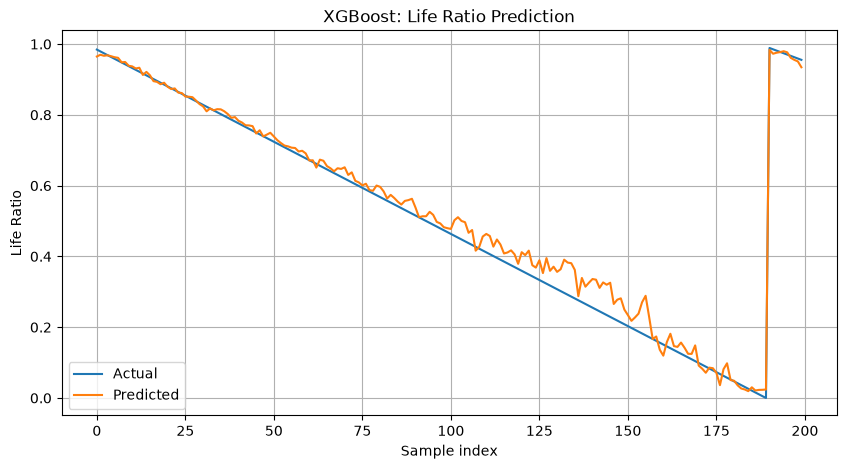

In [36]:
# Plot prediction
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_pred_val[:200], label="Predicted")
plt.title("XGBoost: Life Ratio Prediction")
plt.ylabel("Life Ratio")
plt.xlabel("Sample index")
plt.legend()
plt.grid()
plt.show()

## Model comparison table

The validation-set results for the models trained in this notebook (target: `life_ratio`,
bounded in [0, 1]) are summarized below:

| Model | Dataset | RMSE | MAE | R² |
|---|---|---:|---:|---:|
| Random Forest (Optuna-tuned) | Validation | 0.0571 | 0.0430 | 0.9601 |
| XGBoost (Optuna-tuned) | Validation | 0.0559 | 0.0420 | 0.9617 |

These results suggest that the XGBoost model outperformed the Random Forest baseline on
the validation set for this task.

### Interpretable / Explainable predictions using SHAP

In [37]:
import shap

X_sample = X_val.sample(n=10, random_state=42)

explainer = shap.TreeExplainer(best_xg)
shap_values = explainer(X_sample)



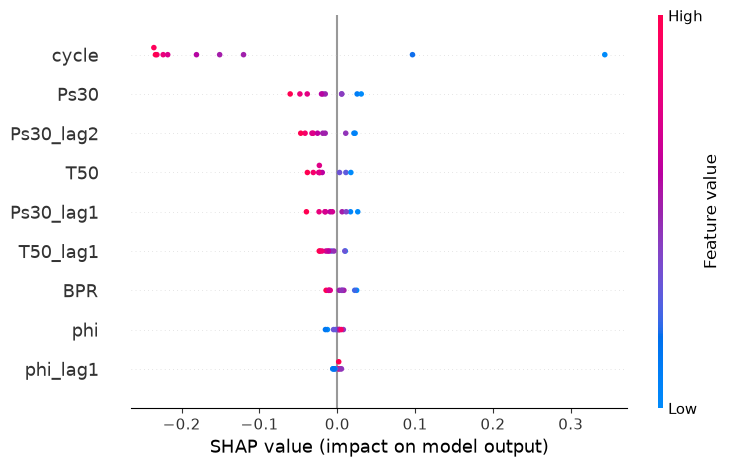

In [38]:
shap.plots.beeswarm(shap_values)

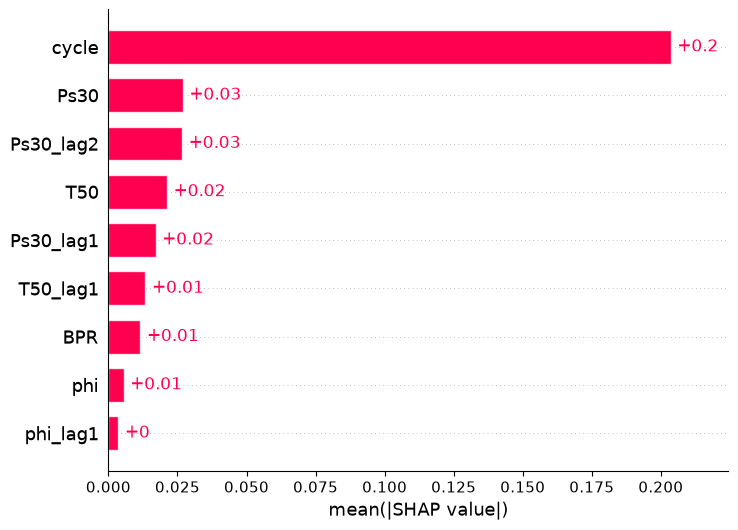

In [39]:
shap.plots.bar(shap_values)

Based on the feature selection scores and SHAP plots, `cycle` and the `Ps30`-derived
features (`Ps30`, its lags, and its rolling mean) contribute the most to life_ratio
predictions, followed by `T50` and `BPR` -- consistent with the top-10 features selected
above. Also consistent with the RUL notebook.

# Evaluation on test set

In [40]:
import pandas as pd
from src.const import RAW_COLUMN_NAMES

# Read raw test data using the same schema as the training data
columns = RAW_COLUMN_NAMES

# Load the raw test file and the provided RUL values
raw_test = pd.read_csv(
    "../data/raw/test_FD001.txt",
    sep=r"\s+",
    header=None,
    usecols=range(len(columns)),
    names=columns,
    engine="python",
)
raw_rul = pd.read_csv("../data/raw/RUL_FD001.txt", sep=r"\s+", header=None).iloc[:, 0]

# Reconstruct RUL for every observed cycle using the provided terminal RUL values.
# The test set is censored (it doesn't run to failure), so life_ratio can't be
# computed with add_life_ratio() alone -- we need the true total life first.
engine_ids = raw_test["engine_id"].unique()
if len(raw_rul) != len(engine_ids):
    raise ValueError(f"Expected {len(engine_ids)} RUL values, got {len(raw_rul)}")

rul_map = dict(zip(engine_ids, raw_rul.tolist()))
raw_test["rul_at_last_cycle"] = raw_test["engine_id"].map(rul_map)
raw_test["last_cycle"] = raw_test.groupby("engine_id")["cycle"].transform("max")
raw_test["RUL"] = raw_test["rul_at_last_cycle"] + (raw_test["last_cycle"] - raw_test["cycle"])

# Total life = last observed cycle + the RUL still remaining at that cycle
raw_test["total_life"] = raw_test["last_cycle"] + raw_test["rul_at_last_cycle"]
raw_test["life_ratio"] = raw_test["RUL"] / raw_test["total_life"]
raw_test = raw_test.drop(columns=["rul_at_last_cycle", "last_cycle", "RUL", "total_life"])

# Apply the same column drops as training data (skip preprocess(), which assumes
# the dataframe runs to failure -- not true for this censored test set)
raw_test = clean_features(raw_test, cols_to_drop=cols_to_drop)

# Scale using the training-set scaler and create the same engineered features
sensor_cols = get_sensor_columns(raw_test)
raw_test_scaled = raw_test.copy()
raw_test_scaled[sensor_cols] = scaler.transform(raw_test_scaled[sensor_cols])

raw_test_fe = add_time_series_features(raw_test_scaled, sensor_cols)
raw_test_fe = raw_test_fe.dropna().reset_index(drop=True)

# Keep the same feature columns used during model training
raw_test_final = apply_feature_selection(raw_test_fe, selected_features, target="life_ratio")

# Collect processed test data for later evaluation
test_data_processed = [raw_test_final]
test_data_processed = pd.concat(test_data_processed, ignore_index=True)

print("Test preprocessing complete.")
test_data_processed.head()

Test preprocessing complete.


,life_ratio,cycle,engine_id,Ps30,T50,Ps30_lag1,phi,T50_lag1,Ps30_lag2,phi_lag1,BPR
0,0.979021,3,1,-0.149293,-0.840916,-0.149293,0.752310,-1.501236,-1.278278,1.010825,0.055314
1,0.972028,4,1,-0.977215,-0.274289,-0.149293,-0.050446,-0.840916,-0.149293,0.752310,-1.341760
2,0.965035,5,1,-0.864317,-0.776222,-0.977215,0.997219,-0.274289,-0.149293,-0.050446,-1.037816
3,0.958042,6,1,-1.052481,-1.533583,-0.864317,0.684280,-0.776222,-0.977215,0.997219,-0.485919
4,0.951049,7,1,-0.864317,-0.450523,-1.052481,0.806734,-1.533583,-0.864317,0.684280,-1.349758


In [41]:
train_final.columns

Index(['life_ratio', 'cycle', 'engine_id', 'Ps30', 'T50', 'Ps30_lag1', 'phi',
       'T50_lag1', 'Ps30_lag2', 'phi_lag1', 'BPR'],
      dtype='object')

In [42]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Prepare features and target for evaluation
X_test = test_data_processed.drop(columns=["life_ratio", "engine_id"], errors="ignore")
y_test = test_data_processed["life_ratio"]

# Use the trained model from the notebook
if "best_xg" not in globals():
    raise NameError("Train a model first (for example, fit best_xg on X_train/y_train).")

# Predict on the test set
y_pred_test = best_xg.predict(X_test)

# Compute evaluation metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae = mean_absolute_error(y_test, y_pred_test)
r2 = r2_score(y_test, y_pred_test)

print("\nTest Performance:")
print(f"RMSE: {rmse:.4f}")
print(f"MAE : {mae:.4f}")
print(f"R2  : {r2:.4f}")


Test Performance:
RMSE: 0.0664
MAE : 0.0472
R2  : 0.9150


# Error Analysis

Mean test residual (Actual - Predicted): 0.010127173281301978


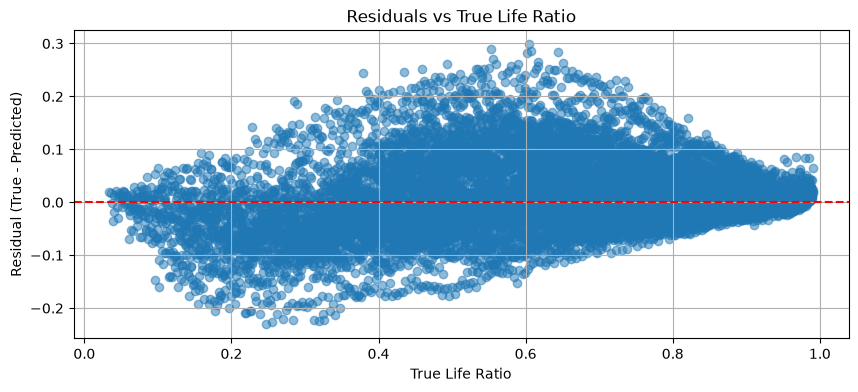

In [43]:
residuals = y_test - y_pred_test
print("Mean test residual (Actual - Predicted):", residuals.mean())

plt.figure(figsize=(10, 4))
plt.scatter(y_test, residuals, alpha=0.5)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("True Life Ratio")
plt.ylabel("Residual (True - Predicted)")
plt.title("Residuals vs True Life Ratio")
plt.grid(True)
plt.show()

On the held-out test set, the mean residual is about +0.010 (Actual - Predicted), a small underprediction on average. Unlike the raw-RUL version of this notebook, the bias here is close to zero relative to the [0, 1] scale of life_ratio.

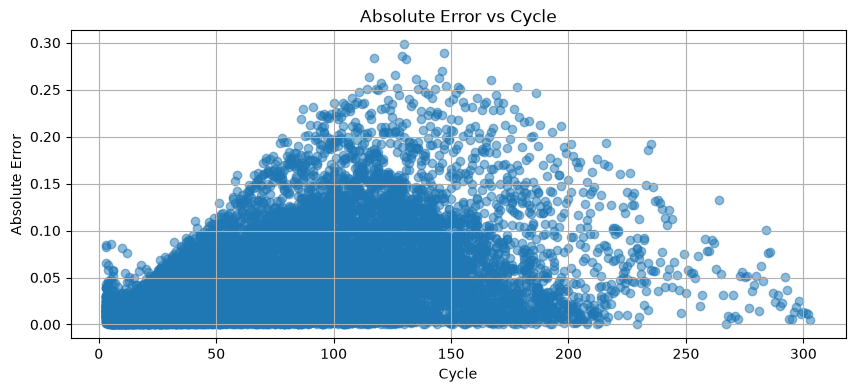

In [44]:
### Error by cycle
plt.figure(figsize=(10, 4))
plt.scatter(test_data_processed["cycle"], np.abs(residuals), alpha=0.5)
plt.xlabel("Cycle")
plt.ylabel("Absolute Error")
plt.title("Absolute Error vs Cycle")
plt.grid(True)
plt.show()


Error is lower near failure, more accurate closer to failure

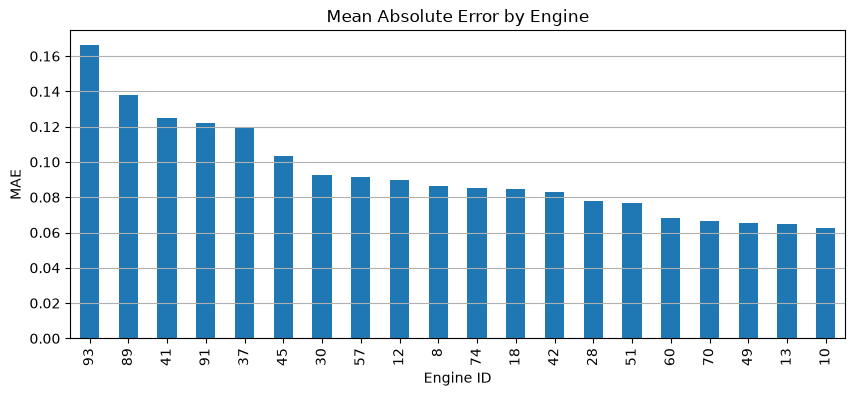

In [45]:
### Error by engine
engine_errors = pd.DataFrame({
    "engine_id": test_data_processed["engine_id"],
    "abs_error": np.abs(residuals)
}).groupby("engine_id")["abs_error"].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 4))
engine_errors.head(20).plot(kind="bar")
plt.title("Mean Absolute Error by Engine")
plt.ylabel("MAE")
plt.xlabel("Engine ID")
plt.grid(axis="y")
plt.show()

Engine 93 has the highest errors

# Classification Evaluation via binning


When life_ratio is below 0.1 (10% of life remaining), we treat the engine as being in a near-failure state and flag it for maintenance attention. This is often more actionable from a business perspective than reporting a raw life_ratio number, because it supports clear operational decisions such as scheduling inspection, maintenance, or replacement.

In [46]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.metrics import classification_report

# Note: threshold should not be tuned using test set
def binary_evaluation(threshold=0.1, pred_offset=0.0):
    # Convert continuous life_ratio into a binary class: 1 = near failure, 0 = not near failure
    y_true_bin = (y_test <= threshold).astype(int)
    y_pred_bin = (y_pred_test <= threshold + pred_offset).astype(int)

    accuracy = accuracy_score(y_true_bin, y_pred_bin)
    precision = precision_score(y_true_bin, y_pred_bin, zero_division=0)
    recall = recall_score(y_true_bin, y_pred_bin, zero_division=0)
    f1 = f1_score(y_true_bin, y_pred_bin, zero_division=0)
    cm = confusion_matrix(y_true_bin, y_pred_bin)

    print("Binary Classification Metrics")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true_bin, y_pred_bin, target_names=["Not Near Failure", "Near Failure"]))

    # Optional: plot confusion matrix
    import seaborn as sns
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Near Failure", "Near Failure"], yticklabels=["Not Near Failure", "Near Failure"])
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix for Near-Failure Classification")
    plt.show()

Binary Classification Metrics
Accuracy : 0.9945
Precision: 0.6949
Recall   : 0.7009
F1-score : 0.6979

Classification Report:
                  precision    recall  f1-score   support

Not Near Failure       1.00      1.00      1.00     12779
    Near Failure       0.69      0.70      0.70       117

        accuracy                           0.99     12896
       macro avg       0.85      0.85      0.85     12896
    weighted avg       0.99      0.99      0.99     12896



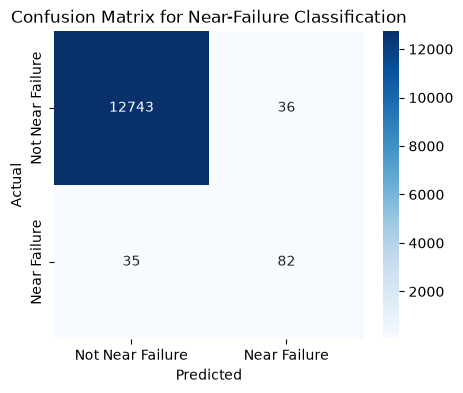

In [47]:
binary_evaluation()

Binary Classification Metrics
Accuracy : 0.9888
Precision: 0.4444
Recall   : 0.9231
F1-score : 0.6000

Classification Report:
                  precision    recall  f1-score   support

Not Near Failure       1.00      0.99      0.99     12779
    Near Failure       0.44      0.92      0.60       117

        accuracy                           0.99     12896
       macro avg       0.72      0.96      0.80     12896
    weighted avg       0.99      0.99      0.99     12896



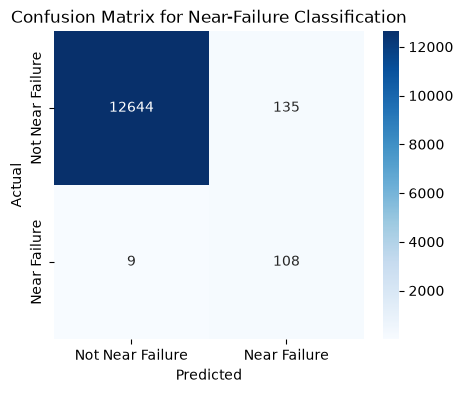

In [48]:
binary_evaluation(pred_offset=0.05)

Because life_ratio is bounded in [0, 1], a prediction offset here is a small ratio
(e.g. 0.05) rather than a cycle count. As before, increasing the offset improves recall
at the cost of precision, letting the business choose the tradeoff between catching more
at-risk engines and tolerating more false alarms.

Example:

Model with offset=0:
- precision = 0.69
- recall = 0.70

Model with offset=0.05:
- precision = 0.44
- recall = 0.92

# Verdict: Life ratio vs RUL

Life ratio often produces better RMSE, R², and classification performance in CMAPSS because it normalizes the degradation trajectory into a bounded and monotonic signal. This makes the learning problem easier by reducing target's variance and normalizing to a [0, 1] scale.

## Future work for model improvements

Several next steps could further improve the model and make the results more robust:

- Add a baseline model comparison table, including simple baselines and more advanced models, to better quantify the gain from the current approach.
- Run an ablation study for lag and rolling features to measure how much each feature group contributes to predictive performance.
- Combine multiple datasets or operating conditions to improve generalization and reduce overfitting to a single fleet or regime.
